In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from datetime import datetime
from torch.utils.data import DataLoader

from pathlib import Path
import random
import numpy as np
import pandas as pd
import os
import json
import time
import copy
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # Auto-detect Jupyter / Terminal

from torchvision.models import resnet50, ResNet50_Weights
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
# Memastikan CUDA (GPU) tersedia
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU terdeteksi: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU tidak terdeteksi, menggunakan CPU.")

GPU terdeteksi: NVIDIA GeForce RTX 4060 Laptop GPU


## Konfigurasi

In [9]:
# ==============================================================================
# 1. PENGATURAN SEED (REPRODUCIBILITY)
# Tujuannya agar jika eksperimen diulang, hasilnya akan tetap sama (konsisten)
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Mengatur agar backend CuDNN berjalan deterministik
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [10]:
# ==============================================================================
# 1. KONFIGURASI PATH (FOLDER DIRECTORY)
# ==============================================================================
# Sesuaikan 'dataset/' dengan nama folder tempat Anda menyimpan data
CURRENT_DIR     = Path.cwd()

if CURRENT_DIR.name == "testing":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

OUTPUT_DIR       = PROJECT_DIR / "dataset" / "testing"
OUTPUT_MODEL     = PROJECT_DIR / "models" / "testing"

LOG_DIR = PROJECT_DIR / "logs" / "traning"


TRAIN_DIR       = OUTPUT_DIR / "train"
VAL_DIR         = OUTPUT_DIR / "val"
TEST_DIR        = PROJECT_DIR / "dataset" / "raw"  / "Dataset" / "GCD" / "test" 
MODEL_SAVE_PATH = OUTPUT_MODEL / 'best_cloud_model.pth' # Nama file ketika model disimpan nanti

OUTPUT_MODEL.mkdir(parents=True, exist_ok=True)

In [11]:
# ==============================================================================
# 1. KONFIGURASI DATASET & DATALOADER
# ==============================================================================
NUM_CLASSES     = 7
IMAGE_SIZE      = 224 # Standar untuk ResNet, MobileNet, dll (224x224)
BATCH_SIZE      = 32  # Turunkan ke 16 atau 8 jika GPU lokal mengalami "Out of Memory"
NUM_WORKERS     = 0   # Gunakan 2 atau 4 (sesuai jumlah core CPU lokal Anda)
HASIL_TRAIN     = [] 

In [12]:
# ==============================================================================
# 2. KONFIGURASI MODEL & TRAINING (HYPERPARAMETERS)
# ==============================================================================
MODEL_NAME      = 'resnet50'  # Referensi nama model yang digunakan
WEIGHTS_MODEL   = 'ResNet50_Weights.IMAGENET1K_V2'
LEARNING_RATE   = 1e-4        # 0.0001 (LR kecil bagus untuk pre-trained model/fine-tuning)
EPOCHS          = 20          # Jumlah iterasi training
SEED_VALUE      = 42          # Angka seed standar
PATIENCE        = 3           # EARLY STOPPING

In [13]:
# ==============================================================================
# 5. EKSEKUSI KONFIGURASI AWAL (SETUP)
# ==============================================================================
# Terapkan Seed
set_seed(SEED_VALUE)

# Cek Ketersediaan GPU Lokal
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print Laporan Konfigurasi
print("-" * 50)
print("⚙️ KONFIGURASI SISTEM & HARDWARE")
print("-" * 50)
print(f"Perangkat yang digunakan : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"Nama GPU Lokal         : {torch.cuda.get_device_name(0)}")
    
print("\n" + "-" * 50)
print("📂 STATUS FOLDER DATASET")
print("-" * 50)
print(f"Folder Train ada? : {TRAIN_DIR.exists()} -> Path: {TRAIN_DIR}")
print(f"Folder Val ada?   : {VAL_DIR.exists()} -> Path: {VAL_DIR}")
print(f"Folder Test ada?  : {TEST_DIR.exists()} -> Path: {TEST_DIR}")
print("-" * 50)

--------------------------------------------------
⚙️ KONFIGURASI SISTEM & HARDWARE
--------------------------------------------------
Perangkat yang digunakan : cuda
Nama GPU Lokal         : NVIDIA GeForce RTX 4060 Laptop GPU

--------------------------------------------------
📂 STATUS FOLDER DATASET
--------------------------------------------------
Folder Train ada? : True -> Path: d:\n8n-logsiswaparalayang\cloud-classification\dataset\testing\train
Folder Val ada?   : True -> Path: d:\n8n-logsiswaparalayang\cloud-classification\dataset\testing\val
Folder Test ada?  : True -> Path: d:\n8n-logsiswaparalayang\cloud-classification\dataset\raw\Dataset\GCD\test
--------------------------------------------------


## Transformasi, Dataset, dan DataLoader

In [33]:
# 1. Setup Transformasi Data
# Normalisasi menggunakan rata-rata dan standar deviasi dari ImageNet
data_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [34]:
# 2. Inisialisasi Dataset menggunakan variabel Pathlib
# PyTorch ImageFolder menerima objek Pathlib tanpa perlu diubah menjadi string
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=data_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=data_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=data_transforms)

# Mengekstrak nama kelas
class_names = train_dataset.classes

print("-" * 50)
print("📊 INFORMASI DATASET")
print("-" * 50)
print(f"Daftar Kelas ({len(class_names)}): {class_names}")
print(f"Jumlah Data Train : {len(train_dataset)}")
print(f"Jumlah Data Val   : {len(val_dataset)}")
print(f"Jumlah Data Test  : {len(test_dataset)}")
print("-" * 50)

--------------------------------------------------
📊 INFORMASI DATASET
--------------------------------------------------
Daftar Kelas (7): ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus', '7_mixed']
Jumlah Data Train : 21000
Jumlah Data Val   : 1998
Jumlah Data Test  : 9000
--------------------------------------------------


In [35]:
# 3. Setup DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Catatan: pin_memory=True digunakan untuk mempercepat transfer data dari CPU RAM ke GPU VRAM.

## Setup Model, Loss Function, dan Optimizer

In [12]:
print("-" * 50)
print(f"🛠️ MEMBANGUN MODEL: {MODEL_NAME.upper()}")
print("-" * 50)

# 1. Load Pre-trained Model
# Menggunakan weights terbaru (IMAGENET1K_V2) untuk akurasi dasar yang lebih baik
weights = WEIGHTS_MODEL
model = models.resnet50(weights=weights)

# 2. Modifikasi Layer Terakhir (Classifier)
# Mengambil jumlah fitur input dari layer fully connected terakhir
num_ftrs = model.fc.in_features

# Mengganti layer terakhir agar outputnya 7 (sesuai jumlah kelas awan)
model.fc = nn.Linear(num_ftrs, NUM_CLASSES)

# 3. Pindahkan Model ke Perangkat (GPU/CPU)
model = model.to(DEVICE)

# 4. Tentukan Loss Function dan Optimizer
# criterion = nn.CrossEntropyLoss()

# Hanya optimize parameter yang butuh update. Menggunakan Adam optimizer.
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Model berhasil disiapkan dan dipindahkan ke: {DEVICE}")
print(f"Total kelas pada layer output: {model.fc.out_features}")
print("-" * 50)

--------------------------------------------------
🛠️ MEMBANGUN MODEL: RESNET50
--------------------------------------------------
Model berhasil disiapkan dan dipindahkan ke: cuda
Total kelas pada layer output: 7
--------------------------------------------------


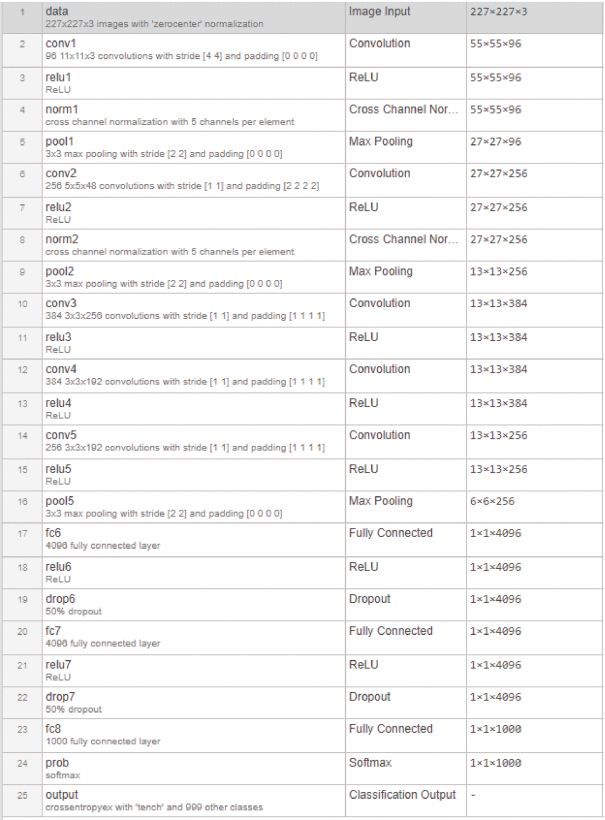

In [64]:
class CNNBaseline(nn.Module):
    def __init__(self,num_classes=NUM_CLASSES):
        super(CNNBaseline, self).__init__()
        self.features = nn.Sequential(
            # Baris 2: conv1 (96 filter ukuran 11x11, stride 4, padding 0)
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=0),
            # Baris 3: relu1
            nn.ReLU(inplace=True),
            # Baris 4: norm1 (Cross Channel Normalization / LRN)
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=1.0),
            # Baris 5: pool1 (3x3 max pooling, stride 2, padding 0)
            nn.MaxPool2d(kernel_size=3, stride=2, padding=0),

            # Baris 6: conv2 (256 filter ukuran 5x5, stride 1, padding 2)
            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2),
            # Baris 7: relu2
            nn.ReLU(inplace=True),
            # Baris 8: norm2
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=1.0),
            # Baris 9: pool2 (3x3 max pooling, stride 2, padding 0)
            nn.MaxPool2d(kernel_size=3, stride=2, padding=0),

            # Baris 10: conv3 (384 filter ukuran 3x3, stride 1, padding 1)
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1),
            # Baris 11: relu3
            nn.ReLU(inplace=True),

            # Baris 12: conv4 (384 filter ukuran 3x3, stride 1, padding 1)
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1),
            # Baris 13: relu4
            nn.ReLU(inplace=True),

            # Baris 14: conv5 (256 filter ukuran 3x3, stride 1, padding 1)
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1),
            # Baris 15: relu5
            nn.ReLU(inplace=True),
            # Baris 16: pool5 (3x3 max pooling, stride 2, padding 0) -> Output spasial menjadi 6x6
            nn.MaxPool2d(kernel_size=3, stride=2, padding=0)
        )

        # Klasifikasi / Fully Connected Layers (Baris 17 s.d. 24)
        self.classifier = nn.Sequential(
             nn.AdaptiveAvgPool2d((6, 6)), 
            nn.Flatten(), # Mengubah tensor [Batch, 256, 6, 6] menjadi vektor [Batch, 9216]
            
            # Baris 17 & 18: fc6 & relu6
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            # Baris 19: drop6 (50% dropout)
            nn.Dropout(p=0.5),
            
            # Baris 20 & 21: fc7 & relu7
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            # Baris 22: drop7 (50% dropout)
            nn.Dropout(p=0.8),
            
            # Baris 23: fc8 (Mendekati klasifikasi akhir)
            nn.Linear(4096, num_classes)
            # Catatan: Baris 24 (Softmax) dan Baris 25 (CrossEntropy) biasanya langsung ditangani 
            # secara otomatis dan lebih stabil di dalam fungsi Loss PyTorch yaitu `nn.CrossEntropyLoss()`.
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [65]:
model = CNNBaseline(num_classes=NUM_CLASSES).to(device)
print(model)

CNNBaseline(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=1.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=1.0)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(6

In [70]:
LEARNING_RATE = 0.00001
num_epochs = 30
patience = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [67]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [68]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [71]:
patience = 5

os.makedirs("models", exist_ok=True)

best_val_loss = float("inf")
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_model_path = OUTPUT_MODEL / 'best_cloud_model_baseline.pth'

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "class_names": train_dataset.classes
        }, best_model_path)

        print("Model terbaik disimpan.")
    else:
        patience_counter += 1
        print(f"Early stopping counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Training dihentikan karena early stopping.")
        break

Epoch [1/20] Train Loss: 0.8940 | Train Acc: 0.6471 | Val Loss: 0.7496 | Val Acc: 0.7252
Model terbaik disimpan.
Epoch [2/20] Train Loss: 0.8503 | Train Acc: 0.6660 | Val Loss: 0.7233 | Val Acc: 0.7297
Model terbaik disimpan.
Epoch [3/20] Train Loss: 0.8284 | Train Acc: 0.6709 | Val Loss: 0.7011 | Val Acc: 0.7397
Model terbaik disimpan.
Epoch [4/20] Train Loss: 0.8073 | Train Acc: 0.6804 | Val Loss: 0.6984 | Val Acc: 0.7402
Model terbaik disimpan.
Epoch [5/20] Train Loss: 0.7938 | Train Acc: 0.6865 | Val Loss: 0.6784 | Val Acc: 0.7482
Model terbaik disimpan.
Epoch [6/20] Train Loss: 0.7784 | Train Acc: 0.6918 | Val Loss: 0.6662 | Val Acc: 0.7528
Model terbaik disimpan.
Epoch [7/20] Train Loss: 0.7676 | Train Acc: 0.6938 | Val Loss: 0.6653 | Val Acc: 0.7513
Model terbaik disimpan.
Epoch [8/20] Train Loss: 0.7580 | Train Acc: 0.6980 | Val Loss: 0.6450 | Val Acc: 0.7633
Model terbaik disimpan.
Epoch [9/20] Train Loss: 0.7453 | Train Acc: 0.7062 | Val Loss: 0.6504 | Val Acc: 0.7558
Early s

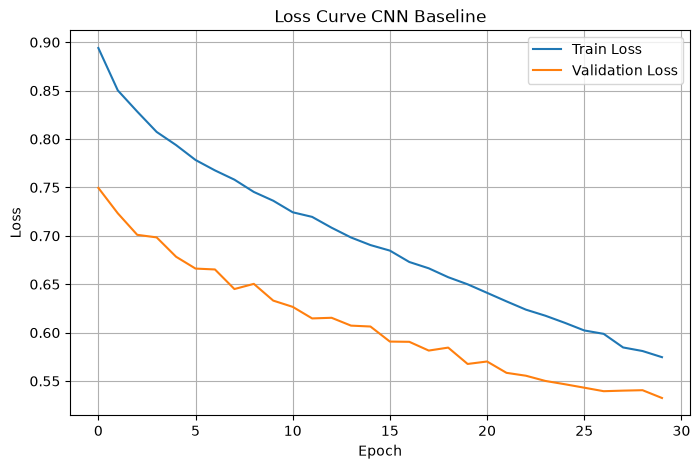

In [72]:
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Curve CNN Baseline")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(LOG_DIR / "baseline_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
checkpoint = torch.load(best_model_path, map_location=device)

model = CNNBaseline(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model terbaik berhasil dimuat")
print("Epoch terbaik:", checkpoint["epoch"])
print("Validation loss terbaik:", checkpoint["best_val_loss"])

Model terbaik berhasil dimuat
Epoch terbaik: 30
Validation loss terbaik: 0.5324856703606872


In [87]:
# Cetak daftar kelas dan totalnya
print("Daftar Kelas:", train_dataset.classes)
print("Total Kelas Riil:", len(train_dataset.classes))

# Samakan nilai NUM_CLASSES dengan total kelas riil tersebut
NUM_CLASSES = len(train_dataset.classes) 

Daftar Kelas: ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus', '7_mixed']
Total Kelas Riil: 7


In [14]:
# ==========================================
# KONFIGURASI PARAMETER (SESUAI SPEK ANDA)
# ==========================================
NUM_CLASSES = NUM_CLASSES = len(train_dataset.classes)
NUM_EPOCHS = 30           # Menggunakan 30 Epoch seperti Baseline Anda
PATIENCE = 5              # Toleransi Early Stopping
LEARNING_RATE = 0.0001    # Sedikit dinaikkan (1e-4) agar classifier baru cepat beradaptasi
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inisialisasi Model ResNet-50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Freeze Backbone
for param in model.parameters():
    param.requires_grad = False

# Ganti Kepala Klasifikasi
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)
model = model.to(DEVICE)

# Loss & Optimizer (Hanya update parameter classifier yang aktif)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

In [15]:
# Tempat menyimpan riwayat metrik untuk grafik nanti
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0

print("Memulai pelatihan ResNet-50 dengan Transfer Learning...")

for epoch in range(NUM_EPOCHS):
    # ------------------------------------------
    # FASE TRAINING (PELATIHAN)
    # ------------------------------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # Reset gradien
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass & Optimasi
        loss.backward()
        optimizer.step()
        
        # Hitung statistik training
        running_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # Hitung rata-rata loss dan akurasi epoch ini
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # ------------------------------------------
    # FASE VALIDASI
    # ------------------------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Matikan perhitungan gradien agar hemat memori
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Hitung statistik validasi
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # Hitung rata-rata loss dan akurasi epoch ini
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Simpan metrik ke dalam history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    # Cetak performa epoch saat ini
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train -> Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}%")
    print(f"  Val   -> Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2f}%")
    
    # ------------------------------------------
    # LOGIKA EARLY STOPPING (PATIENCE = 5)
    # ------------------------------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Simpan model terbaik jika val_loss mengecil
        torch.save(model.state_dict(), 'best_cloud_model_resnet50.pth')
        print(f"  --> [SAVED] Model terbaik baru disimpan!")
    else:
        patience_counter += 1
        print(f"  --> [PATIENCE] Val Loss tidak turun. Progres: {patience_counter}/{PATIENCE}")
        
    # Hentikan paksa jika counter melebihi batas patience Anda
    if patience_counter >= PATIENCE:
        print(f"\n[Early Stopping] Pelatihan dihentikan di Epoch {epoch+1} karena performa validasi stagnan.")
        break

print("\nPelatihan Selesai!")

Memulai pelatihan ResNet-50 dengan Transfer Learning...

Epoch [1/30]
  Train -> Loss: 0.8973 | Acc: 72.43%
  Val   -> Loss: 0.5249 | Acc: 82.28%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [2/30]
  Train -> Loss: 0.5442 | Acc: 80.54%
  Val   -> Loss: 0.4186 | Acc: 84.13%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [3/30]
  Train -> Loss: 0.4713 | Acc: 83.32%
  Val   -> Loss: 0.3871 | Acc: 85.09%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [4/30]
  Train -> Loss: 0.4355 | Acc: 84.14%
  Val   -> Loss: 0.3675 | Acc: 86.29%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [5/30]
  Train -> Loss: 0.4156 | Acc: 85.04%
  Val   -> Loss: 0.3518 | Acc: 86.14%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [6/30]
  Train -> Loss: 0.3833 | Acc: 86.01%
  Val   -> Loss: 0.3402 | Acc: 86.34%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [7/30]
  Train -> Loss: 0.3718 | Acc: 86.53%
  Val   -> Loss: 0.3284 | Acc: 87.54%
  --> [SAVED] Model terbaik baru disimpan!

Epoch [8/30]

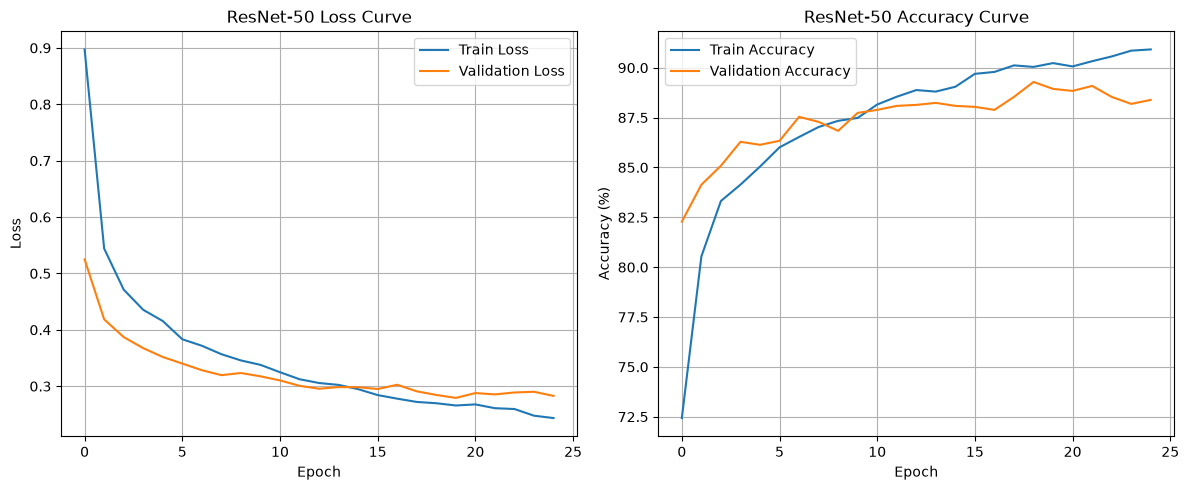

In [16]:
import matplotlib.pyplot as plt

# Plot Kurva Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('ResNet-50 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Kurva Akurasi
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('ResNet-50 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [19]:
MODEL_PATH =  PROJECT_DIR / "testing" / "best_cloud_model_resnet50.pth"

In [20]:
print(f"Memuat model terbaik dari: {MODEL_PATH}")

Memuat model terbaik dari: d:\n8n-logsiswaparalayang\cloud-classification\testing\best_cloud_model_resnet50.pth



Mengumpulkan hasil prediksi dari data validasi...


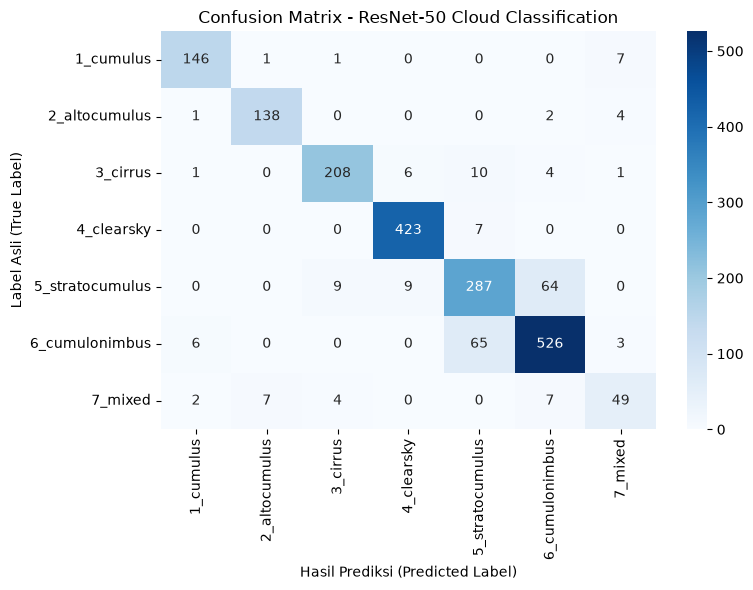


=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

      1_cumulus       0.94      0.94      0.94       155
  2_altocumulus       0.95      0.95      0.95       145
       3_cirrus       0.94      0.90      0.92       230
     4_clearsky       0.97      0.98      0.97       430
5_stratocumulus       0.78      0.78      0.78       369
 6_cumulonimbus       0.87      0.88      0.87       600
        7_mixed       0.77      0.71      0.74        69

       accuracy                           0.89      1998
      macro avg       0.89      0.88      0.88      1998
   weighted avg       0.89      0.89      0.89      1998



In [22]:
# ==========================================
# 2. LOAD MODEL ARSITEKTUR RESNET-50
# ==========================================
model = resnet50()
# Sesuaikan classifier head agar strukturnya sama persis dengan yang Anda latih
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat bobot terbaik (weights) yang berhasil disimpan
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ==========================================
# 3. KUMPULKAN PREDIKSI DAN LABEL ASLI
# ==========================================
all_preds = []
all_labels = []

print("\nMengumpulkan hasil prediksi dari data validasi...")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        # Pindahkan ke CPU dan ubah ke numpy array
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. HITUNG & TAMPILKAN CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

# Visualisasi menggunakan Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ResNet-50 Cloud Classification')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Hasil Prediksi (Predicted Label)')
plt.tight_layout()

# Simpan hasil gambar matrix
plt.savefig('resnet50_confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# 5. CETAK CLASSIFICATION REPORT (METRIK TAMBAHAN)
# ==========================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [1]:
# Transformasi wajib (224x224 & Normalisasi ImageNet)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Memuat Dataset Test
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

NameError: name 'transforms' is not defined

Sedang mengevaluasi data test, mohon tunggu...

         HASIL EVALUASI AKHIR (DATA TEST)        
                 precision    recall  f1-score   support

      1_cumulus       0.91      0.68      0.77       750
  2_altocumulus       0.90      0.46      0.61       750
       3_cirrus       0.64      0.85      0.73       753
     4_clearsky       0.96      0.98      0.97      1589
5_stratocumulus       0.61      0.62      0.61      1790
 6_cumulonimbus       0.69      0.82      0.75      2761
        7_mixed       0.75      0.39      0.51       607

       accuracy                           0.74      9000
      macro avg       0.78      0.69      0.71      9000
   weighted avg       0.76      0.74      0.74      9000


Grafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix.png'


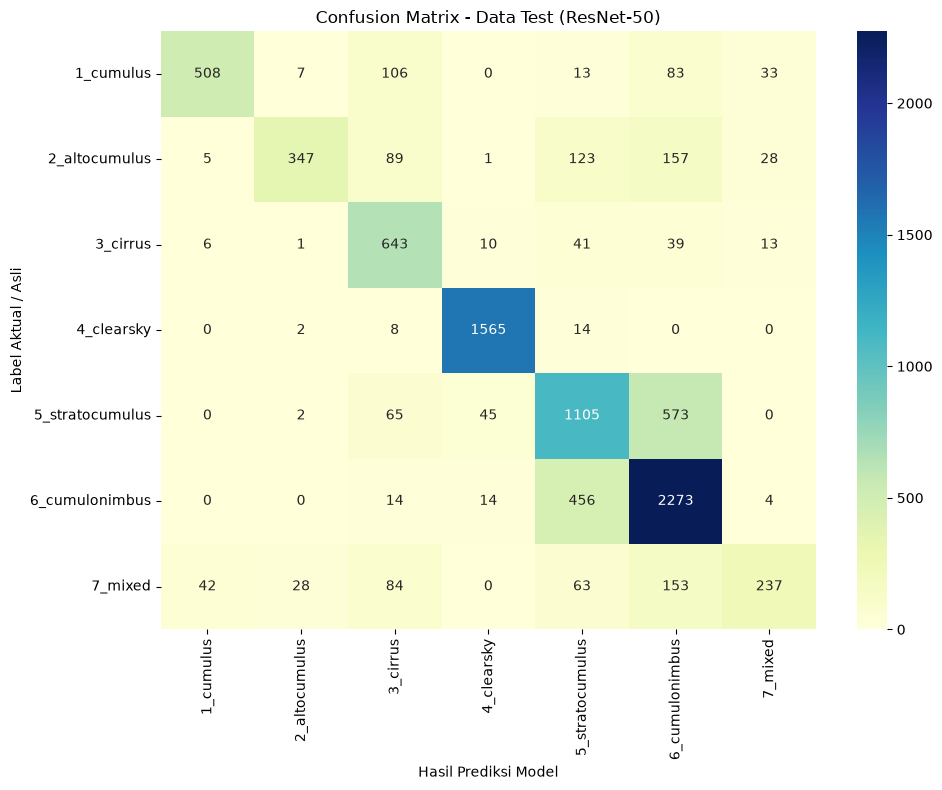

In [24]:
# ==========================================
# 2. MEMUAT ARSITEKTUR & BOBOT MODEL
# ==========================================
model = resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat file .pth hasil training transfer learning kemarin
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval() # Mengaktifkan mode evaluasi (mematikan dropout)

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. TAMPILKAN HASIL AKHIR (CLASSIFICATION REPORT)
# ==========================================
print("\n" + "="*50)
print("         HASIL EVALUASI AKHIR (DATA TEST)        ")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 5. VISUALISASI CONFUSION MATRIX DATA TEST
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Data Test (ResNet-50)')
plt.ylabel('Label Aktual / Asli')
plt.xlabel('Hasil Prediksi Model')
plt.tight_layout()

# Simpan matriks data test secara terpisah
plt.savefig('resnet50_test_confusion_matrix.png', dpi=300)
print("\nGrafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix.png'")
plt.show()

# Fine-Tuning

In [39]:
import torch.nn.functional as F

In [ ]:
# ==========================================
# 1. PARAMETER & KONFIGURASI
# ==========================================
NUM_CLASSES = 7
BATCH_SIZE = 32
NUM_EPOCHS = 20           # Fine-tuning tidak butuh epoch terlalu banyak
PATIENCE = 5              # Early stopping lebih sensitif
LEARNING_RATE = 1e-6  # Super kecil (1e-5) agar bobot tidak rusak!

In [51]:
class CloudFocalLoss(nn.Module):
    def __init__(self, gamma=0.8, reduction='mean', eps=1e-7):
        """
        Focal Loss dengan pengaman stabilitas numerik (eps) 
        untuk mencegah nilai 'nan' saat Full Fine-Tuning.
        """
        super(CloudFocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.eps = eps # <-- Nilai pengaman matematika

    def forward(self, inputs, targets):
        # 1. Hitung probabilitas menggunakan softmax biasa
        p = F.softmax(inputs, dim=-1)
        
        # 2. Ambil probabilitas khusus untuk kelas target yang benar
        pt = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        
        # 3. Tambahkan EPSILON pada pt agar tidak pernah bernilai mutlak 0 atau 1
        pt = torch.clamp(pt, self.eps, 1.0 - self.eps)

        # 4. Terapkan rumus matematika Focal Loss dengan Gamma = 0.8 yang aman
        loss = -1 * ((1 - pt) ** self.gamma) * torch.log(pt)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [52]:
# ==========================================
# 3. MUAT MODEL & KONFIGURASI PARSIAL UNFREEZE
# ==========================================
model = models.resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Wajib muat bobot hasil latihan transfer learning Anda sebelumnya
model.load_state_dict(torch.load('best_cloud_model_resnet50.pth', map_location=DEVICE))

# --- PROSES UNFREEZE PARSIAL ---
# Pertama, bekukan seluruh parameter model terlebih dahulu
for param in model.parameters():
    param.requires_grad = False

# Kedua, buka kunci khusus untuk LAYER 4 (Blok konvolusi teratas ResNet)
for param in model.layer4.parameters():
    param.requires_grad = True

# Ketiga, pastikan lapisan CLASSIFIER baru Anda tetap aktif terbuka kuncinya
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

# Verifikasi parameter mana saja yang akan dilatih ulang
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameter aktif yang akan di-Fine-Tune: {trainable_params:,}")

# ==========================================
# 4. OPTIMIZER & LOSS FUNCTION
# ==========================================

# criterion = nn.CrossEntropyLoss()
criterion = CloudFocalLoss(gamma=0.2) # Menggunakan Focal Loss stabil yang kita perbaiki sebelumnya

# Filter hanya parameter aktif (layer4 + fc) yang didaftarkan ke optimizer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
# optimizer = optim.SGD(
#     filter(lambda p: p.requires_grad, model.parameters()), 
#     lr=LEARNING_RATE, 
#     momentum=0.9, 
#     weight_decay=1e-4
# )

# ==========================================
# 5. FINE-TUNING TRAINING LOOP
# ==========================================
best_val_loss = float('inf')
patience_counter = 0

print("\n--- Memulai Proses Fine-Tuning Parsial (Layer 4) ---")
for epoch in range(NUM_EPOCHS):
    # --- PHASE TRAINING ---
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # --- PHASE VALIDASI ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # Cek Early Stopping berdasarkan parameter Patience Anda
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Simpan bobot fine-tuned terbaik dengan nama file baru agar tidak menimpa yang lama
        torch.save(model.state_dict(), 'best_cloud_model_resnet50_finetuned_and_CloudFocalLoss.pth')
        print("  --> [SAVED] Model fine-tuned terbaik disimpan!")
    else:
        patience_counter += 1
        print(f"  --> [PATIENCE] Kemajuan: {patience_counter}/{PATIENCE}")
        
    if patience_counter >= PATIENCE:
        print("\n[Early Stopping] Proses fine-tuning dihentikan karena tidak ada penurunan loss.")
        break

print("\nFine-Tuning Selesai!")

Total parameter aktif yang akan di-Fine-Tune: 15,491,079

--- Memulai Proses Fine-Tuning Parsial (Layer 4) ---
Epoch [1/15] | Train Loss: 0.2263 | Val Loss: 0.2623
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [2/15] | Train Loss: 0.2197 | Val Loss: 0.2698
  --> [PATIENCE] Kemajuan: 1/4
Epoch [3/15] | Train Loss: 0.2120 | Val Loss: 0.2533
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [4/15] | Train Loss: 0.2147 | Val Loss: 0.2501
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [5/15] | Train Loss: 0.2099 | Val Loss: 0.2512
  --> [PATIENCE] Kemajuan: 1/4
Epoch [6/15] | Train Loss: 0.2011 | Val Loss: 0.2424
  --> [SAVED] Model fine-tuned terbaik disimpan!
Epoch [7/15] | Train Loss: 0.1999 | Val Loss: 0.2536
  --> [PATIENCE] Kemajuan: 1/4
Epoch [8/15] | Train Loss: 0.1984 | Val Loss: 0.2560
  --> [PATIENCE] Kemajuan: 2/4
Epoch [9/15] | Train Loss: 0.1904 | Val Loss: 0.2482
  --> [PATIENCE] Kemajuan: 3/4
Epoch [10/15] | Train Loss: 0.1903 | Val Loss: 0.2437
  --> [

In [53]:
MODEL_PATH =  PROJECT_DIR / "testing" / "best_cloud_model_resnet50_finetuned_and_CloudFocalLoss.pth"

Sedang mengevaluasi data test, mohon tunggu...

         HASIL EVALUASI AKHIR (DATA TEST)        
                 precision    recall  f1-score   support

      1_cumulus       0.91      0.67      0.78       750
  2_altocumulus       0.89      0.47      0.61       750
       3_cirrus       0.65      0.85      0.74       753
     4_clearsky       0.96      0.98      0.97      1589
5_stratocumulus       0.61      0.58      0.59      1790
 6_cumulonimbus       0.68      0.85      0.75      2761
        7_mixed       0.79      0.39      0.52       607

       accuracy                           0.74      9000
      macro avg       0.78      0.68      0.71      9000
   weighted avg       0.76      0.74      0.73      9000


Grafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix-Fine-Tuning.png'


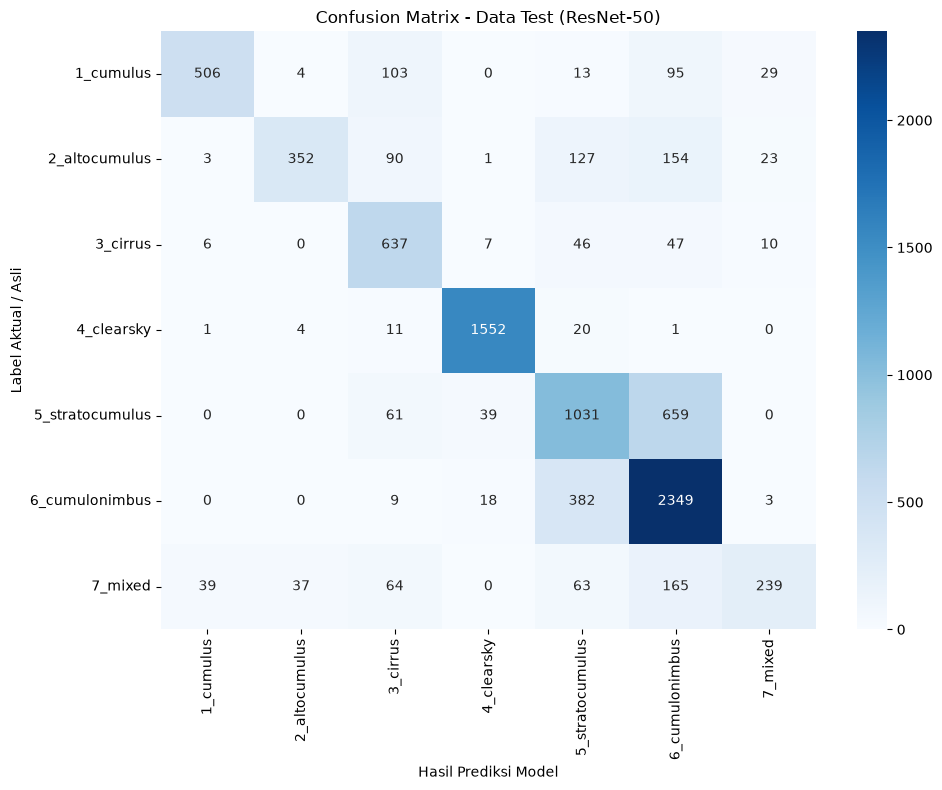

In [54]:
# ==========================================
# 2. MEMUAT ARSITEKTUR & BOBOT MODEL
# ==========================================
model = resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat file .pth hasil training transfer learning kemarin
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval() # Mengaktifkan mode evaluasi (mematikan dropout)

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. TAMPILKAN HASIL AKHIR (CLASSIFICATION REPORT)
# ==========================================
print("\n" + "="*50)
print("         HASIL EVALUASI AKHIR (DATA TEST)        ")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 5. VISUALISASI CONFUSION MATRIX DATA TEST
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Data Test (ResNet-50)')
plt.ylabel('Label Aktual / Asli')
plt.xlabel('Hasil Prediksi Model')
plt.tight_layout()

# Simpan matriks data test secara terpisah
plt.savefig('resnet50_test_confusion_matrix-Fine-Tuning.png', dpi=300)
print("\nGrafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix-Fine-Tuning.png'")
plt.show()

## Discriminative Learning Rates (Unfreeze Semua Layer)

In [31]:
# ==========================================
# 3. MUAT MODEL & UNFREEZE SEMUA LAYER
# ==========================================
model = models.resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Wajib muat bobot dari hasil terbaik Transfer Learning sebelumnya
model.load_state_dict(torch.load('best_cloud_model_resnet50_finetuned.pth', map_location=DEVICE))

# Buka Kunci SEMUA Parameter (requires_grad = True)
for param in model.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

# ==========================================
# 4. STRATEGI A: DISCRIMINATIVE LEARNING RATES
# ==========================================
# Mengelompokkan parameter dengan tingkat kecepatan belajar yang berbeda
optimizer = optim.Adam([
    # Lapisan awal (Deteksi garis/tepi): Sangat lambat agar tidak rusak
    {'params': model.conv1.parameters(), 'lr': 1e-6},
    {'params': model.bn1.parameters(),   'lr': 1e-6},
    {'params': model.layer1.parameters(), 'lr': 1e-6},
    
    # Lapisan tengah (Deteksi tekstur/pola dasar): Lambat
    {'params': model.layer2.parameters(), 'lr': 5e-6},
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    
    # Lapisan atas (Deteksi bentuk abstrak awan): Sedang
    {'params': model.layer4.parameters(), 'lr': 2e-5},
    
    # Lapisan Classifier baru: Cepat (Menyesuaikan jumlah kelas)
    {'params': model.fc.parameters(),     'lr': 1e-4}
])

criterion = nn.CrossEntropyLoss()

# ==========================================
# 5. ADVANCED FINE-TUNING LOOP
# ==========================================
best_val_loss = float('inf')
patience_counter = 0

print("\n--- Memulai Full Fine-Tuning dengan Discriminative Learning Rates ---")
for epoch in range(NUM_EPOCHS):
    # --- PHASE TRAINING ---
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # --- PHASE VALIDASI ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # Logika Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Simpan dengan nama file baru agar tidak menimpa model lama
        torch.save(model.state_dict(), 'best_cloud_model_resnet50_discriminative.pth')
        print("  --> [SAVED] Model SOTA terbaik disimpan!")
    else:
        patience_counter += 1
        print(f"  --> [PATIENCE] Kemajuan: {patience_counter}/{PATIENCE}")
        
    if patience_counter >= PATIENCE:
        print("\n[Early Stopping] Pelatihan dihentikan karena loss validasi telah optimal.")
        break

print("\nTuning Lanjutan Selesai!")


--- Memulai Full Fine-Tuning dengan Discriminative Learning Rates ---
Epoch [1/15] | Train Loss: 0.0843 | Val Loss: 0.2722
  --> [SAVED] Model SOTA terbaik disimpan!
Epoch [2/15] | Train Loss: 0.0662 | Val Loss: 0.2572
  --> [SAVED] Model SOTA terbaik disimpan!
Epoch [3/15] | Train Loss: 0.0557 | Val Loss: 0.2688
  --> [PATIENCE] Kemajuan: 1/4
Epoch [4/15] | Train Loss: 0.0494 | Val Loss: 0.2558
  --> [SAVED] Model SOTA terbaik disimpan!
Epoch [5/15] | Train Loss: 0.0383 | Val Loss: 0.2793
  --> [PATIENCE] Kemajuan: 1/4
Epoch [6/15] | Train Loss: 0.0341 | Val Loss: 0.2899
  --> [PATIENCE] Kemajuan: 2/4
Epoch [7/15] | Train Loss: 0.0346 | Val Loss: 0.2924
  --> [PATIENCE] Kemajuan: 3/4
Epoch [8/15] | Train Loss: 0.0222 | Val Loss: 0.3049
  --> [PATIENCE] Kemajuan: 4/4

[Early Stopping] Pelatihan dihentikan karena loss validasi telah optimal.

Tuning Lanjutan Selesai!


## Implementasi Focal Loss dengan Gamma = 0.8

In [34]:
class CloudFocalLoss(nn.Module):
    def __init__(self, gamma=0.8, reduction='mean', eps=1e-7):
        """
        Focal Loss dengan pengaman stabilitas numerik (eps) 
        untuk mencegah nilai 'nan' saat Full Fine-Tuning.
        """
        super(CloudFocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.eps = eps # <-- Nilai pengaman matematika

    def forward(self, inputs, targets):
        # 1. Hitung probabilitas menggunakan softmax biasa
        p = F.softmax(inputs, dim=-1)
        
        # 2. Ambil probabilitas khusus untuk kelas target yang benar
        pt = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        
        # 3. Tambahkan EPSILON pada pt agar tidak pernah bernilai mutlak 0 atau 1
        pt = torch.clamp(pt, self.eps, 1.0 - self.eps)

        # 4. Terapkan rumus matematika Focal Loss dengan Gamma = 0.8 yang aman
        loss = -1 * ((1 - pt) ** self.gamma) * torch.log(pt)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [35]:
# ==========================================
# 3. MUAT MODEL & UNFREEZE SEMUA LAYER
# ==========================================
model = models.resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Wajib muat bobot dari hasil terbaik Transfer Learning sebelumnya
model.load_state_dict(torch.load('best_cloud_model_resnet50_finetuned.pth', map_location=DEVICE))

# Buka Kunci SEMUA Parameter (requires_grad = True)
for param in model.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

# ==========================================
# 4. STRATEGI A: DISCRIMINATIVE LEARNING RATES
# ==========================================
# Mengelompokkan parameter dengan tingkat kecepatan belajar yang berbeda
optimizer = optim.Adam([
    # Lapisan awal (Deteksi garis/tepi): Sangat lambat agar tidak rusak
    {'params': model.conv1.parameters(), 'lr': 1e-6},
    {'params': model.bn1.parameters(),   'lr': 1e-6},
    {'params': model.layer1.parameters(), 'lr': 1e-6},
    
    # Lapisan tengah (Deteksi tekstur/pola dasar): Lambat
    {'params': model.layer2.parameters(), 'lr': 5e-6},
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    
    # Lapisan atas (Deteksi bentuk abstrak awan): Sedang
    {'params': model.layer4.parameters(), 'lr': 2e-5},
    
    # Lapisan Classifier baru: Cepat (Menyesuaikan jumlah kelas)
    {'params': model.fc.parameters(),     'lr': 1e-4}
])

criterion = CloudFocalLoss(gamma=0.8)

# ==========================================
# 5. ADVANCED FINE-TUNING LOOP
# ==========================================
best_val_loss = float('inf')
patience_counter = 0

print("\n--- Memulai Full Fine-Tuning dengan Discriminative Learning Rates ---")
for epoch in range(NUM_EPOCHS):
    # --- PHASE TRAINING ---
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # --- PHASE VALIDASI ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # Logika Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Simpan dengan nama file baru agar tidak menimpa model lama
        torch.save(model.state_dict(), 'best_cloud_model_resnet50_discriminative.pth')
        print("  --> [SAVED] Model SOTA terbaik disimpan!")
    else:
        patience_counter += 1
        print(f"  --> [PATIENCE] Kemajuan: {patience_counter}/{PATIENCE}")
        
    if patience_counter >= PATIENCE:
        print("\n[Early Stopping] Pelatihan dihentikan karena loss validasi telah optimal.")
        break

print("\nTuning Lanjutan Selesai!")


--- Memulai Full Fine-Tuning dengan Discriminative Learning Rates ---
Epoch [1/15] | Train Loss: 0.0452 | Val Loss: 0.1921
  --> [SAVED] Model SOTA terbaik disimpan!
Epoch [2/15] | Train Loss: 0.0411 | Val Loss: 0.1887
  --> [SAVED] Model SOTA terbaik disimpan!
Epoch [3/15] | Train Loss: 0.0342 | Val Loss: 0.1684
  --> [SAVED] Model SOTA terbaik disimpan!
Epoch [4/15] | Train Loss: 0.0281 | Val Loss: 0.1860
  --> [PATIENCE] Kemajuan: 1/4
Epoch [5/15] | Train Loss: 0.0258 | Val Loss: 0.1910
  --> [PATIENCE] Kemajuan: 2/4
Epoch [6/15] | Train Loss: 0.0242 | Val Loss: 0.1982
  --> [PATIENCE] Kemajuan: 3/4
Epoch [7/15] | Train Loss: 0.0178 | Val Loss: 0.1829
  --> [PATIENCE] Kemajuan: 4/4

[Early Stopping] Pelatihan dihentikan karena loss validasi telah optimal.

Tuning Lanjutan Selesai!


In [37]:
MODEL_PATH =  PROJECT_DIR / "testing" / "best_cloud_model_resnet50_discriminative.pth"

Sedang mengevaluasi data test, mohon tunggu...

         HASIL EVALUASI AKHIR (DATA TEST)        
                 precision    recall  f1-score   support

      1_cumulus       0.89      0.69      0.78       750
  2_altocumulus       0.88      0.49      0.63       750
       3_cirrus       0.67      0.86      0.76       753
     4_clearsky       0.98      0.98      0.98      1589
5_stratocumulus       0.59      0.57      0.58      1790
 6_cumulonimbus       0.68      0.83      0.75      2761
        7_mixed       0.81      0.44      0.57       607

       accuracy                           0.74      9000
      macro avg       0.79      0.70      0.72      9000
   weighted avg       0.76      0.74      0.74      9000


Grafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix_Focal_Loss.png'


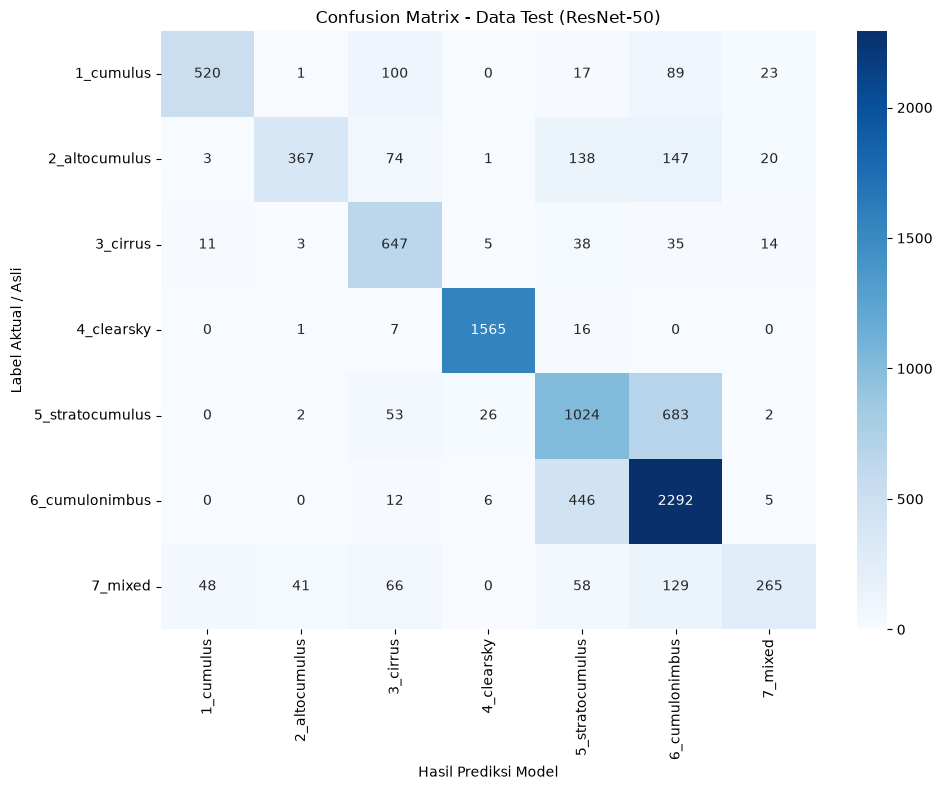

In [38]:
# ==========================================
# 2. MEMUAT ARSITEKTUR & BOBOT MODEL
# ==========================================
model = resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat file .pth hasil training transfer learning kemarin
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval() # Mengaktifkan mode evaluasi (mematikan dropout)

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. TAMPILKAN HASIL AKHIR (CLASSIFICATION REPORT)
# ==========================================
print("\n" + "="*50)
print("         HASIL EVALUASI AKHIR (DATA TEST)        ")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 5. VISUALISASI CONFUSION MATRIX DATA TEST
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Data Test (ResNet-50)')
plt.ylabel('Label Aktual / Asli')
plt.xlabel('Hasil Prediksi Model')
plt.tight_layout()

# Simpan matriks data test secara terpisah
plt.savefig('resnet50_test_confusion_matrix.png', dpi=300)
print("\nGrafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix_Focal_Loss.png'")
plt.show()

## Implementasi Skrip Pelatihan Multi-Stage

In [ ]:
MODEL_PATH =  PROJECT_DIR / "testing" / "best_cloud_model_resnet50_finetuned.pth"

In [24]:
# ========================================================
# FUNGSIONALITAS UTAMA UNTUK MENGATUR LOCK/UNLOCK LAYER
# ========================================================
def set_trainable_layers(model, stage):
    """
    Mengatur parameter yang aktif (requires_grad) berdasarkan tahapan instruksi.
    """
    # Bekukan semua parameter terlebih dahulu
    for param in model.parameters():
        param.requires_grad = False
        
    if stage in [1, 2]:
        # Tahap 1 & 2: Hanya latih bagian Top (Classifier Head)
        for param in model.fc.parameters():
            param.requires_grad = True
        print(f"-> [Stage {stage}] Hanya lapisan TOP (model.fc) yang aktif.")
        
    elif stage in [3, 4]:
        # Tahap 3 & 4: Unfreeze parameter SETELAH blok konvolusi ke-3 (yaitu Layer 4 + FC)
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True
        print(f"-> [Stage {stage}] Parameter SETELAH blok ke-3 aktif (Layer 4 & FC).")
        
    elif stage == 5:
        # Tahap 5: Defrost (Unfreeze) seluruh layer model secara total
        for param in model.parameters():
            param.requires_grad = True
        print(f"-> [Stage {stage}] SELURUH LAPISAN MODEL DIAKTIFKAN (Full Defrost).")

# ========================================================
# FUNGSI RUNNING TRAINING PER STAGE
# ========================================================
def run_training_stage(model, stage_num, epochs, lr, train_loader, val_loader, criterion, device, history):
    print(f"\n=======================================================")
    print(f" STARTING STAGE {stage_num}: Train {epochs} Epochs with LR = {lr}")
    print(f"=======================================================")
    
    # 1. Atur layer yang aktif
    set_trainable_layers(model, stage_num)
    
    # 2. Definisikan Optimizer khusus untuk parameter yang aktif di stage ini
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    # 3. Jalankan Loop Epoch untuk Stage Ini
    for epoch in range(epochs):
        # --- FASE TRAINING ---
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        
        # --- FASE VALIDASI ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        
        # Catat riwayat pencapaian
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        
        print(f"Stage {stage_num} | Global Epoch {len(history['train_loss'])} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
        # Simpan checkpoint cadangan di setiap akhir stage
        if epoch == epochs - 1:
            torch.save(model.state_dict(), f'model_checkpoint_stage_{stage_num}.pth')

# ========================================================
# PROSES EKSEKUSI PIPELINE MULTI-STAGE
# ========================================================
# Wadah global untuk mencatat grafik loss dari ke-5 tahapan beruntun
pipeline_history = {'train_loss': [], 'val_loss': []}

# PENTING: Gunakan arsitektur dasar Anda & muat bobot awal ImageNet bersih
model = models.resnet50()
# (Sesuaikan susunan model.fc Anda di sini agar memiliki NUM_CLASSES = 7)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, 7)
)
model = model.to(DEVICE)
criterion = CloudFocalLoss(gamma=0.8) # Menggunakan Focal Loss stabil yang kita perbaiki sebelumnya

# JALANKAN TAHAPAN SESUAI INSTRUKSI ANDA:
# (1) Latih top 10 epoch dengan LR 0.0001
run_training_stage(model, stage_num=1, epochs=10, lr=0.0001, 
                train_loader=train_loader, val_loader=val_loader, criterion=criterion, device=DEVICE, history=pipeline_history)

# (2) Latih top 10 epoch dengan LR 0.00001
run_training_stage(model, stage_num=2, epochs=10, lr=0.00001, 
                train_loader=train_loader, val_loader=val_loader, criterion=criterion, device=DEVICE, history=pipeline_history)

# (3) Unfreeze setelah blok 3, latih 20 epoch dengan LR 0.00005
run_training_stage(model, stage_num=3, epochs=20, lr=0.00005, 
                train_loader=train_loader, val_loader=val_loader, criterion=criterion, device=DEVICE, history=pipeline_history)

# (4) Latih 20 epoch dengan LR 0.00001
run_training_stage(model, stage_num=4, epochs=20, lr=0.00001, 
                train_loader=train_loader, val_loader=val_loader, criterion=criterion, device=DEVICE, history=pipeline_history)

# (5) Defrost total semua layer, latih 20 epoch dengan LR 0.000001
run_training_stage(model, stage_num=5, epochs=20, lr=0.000001, 
                train_loader=train_loader, val_loader=val_loader, criterion=criterion, device=DEVICE, history=pipeline_history)

# Simpan hasil akhir SOTA model
torch.save(model.state_dict(), 'best_cloud_model_resnet50_pipeline_sota.pth')
print("\n[SUKSES LENGKAP] Seluruh tahapan training stage (80 Epoch Total) berhasil diselesaikan!")

# ========================================================
# VISUALISASI GRAFIK PIPELINE UTUH (80 EPOCH CONTINUOUS)
# ========================================================
plt.figure(figsize=(12, 6))
plt.plot(pipeline_history['train_loss'], label='Train Loss (Pipeline)', color='blue')
plt.plot(pipeline_history['val_loss'], label='Validation Loss (Pipeline)', color='orange')
# Membuat garis putus-putus vertikal penanda batas transisi stage agar rapi di grafik
plt.axvline(x=10, color='gray', linestyle=':', label='Stage 2 Switch')
plt.axvline(x=20, color='gray', linestyle='--', label='Stage 3 Switch')
plt.axvline(x=40, color='gray', linestyle='-.', label='Stage 4 Switch')
plt.axvline(x=60, color='red', linestyle='-', label='Stage 5 (Full Defrost)')

plt.title('Continuous Multi-Stage Training Loss Curve (80 Epochs Total)')
plt.xlabel('Global Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('resnet50_pipeline_loss_curve.png', dpi=300)
plt.show()

NameError: name 'CloudFocalLoss' is not defined

In [26]:
MODEL_PATH =  PROJECT_DIR / "testing" / "model_checkpoint_stage_3.pth"

Sedang mengevaluasi data test, mohon tunggu...

         HASIL EVALUASI AKHIR (DATA TEST)        
                 precision    recall  f1-score   support

      1_cumulus       0.89      0.46      0.60       750
  2_altocumulus       0.77      0.18      0.29       750
       3_cirrus       0.51      0.63      0.56       753
     4_clearsky       0.92      0.96      0.94      1589
5_stratocumulus       0.57      0.67      0.62      1790
 6_cumulonimbus       0.65      0.77      0.70      2761
        7_mixed       0.42      0.31      0.36       607

       accuracy                           0.67      9000
      macro avg       0.68      0.57      0.58      9000
   weighted avg       0.68      0.67      0.65      9000


Grafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix_pipeline.png'


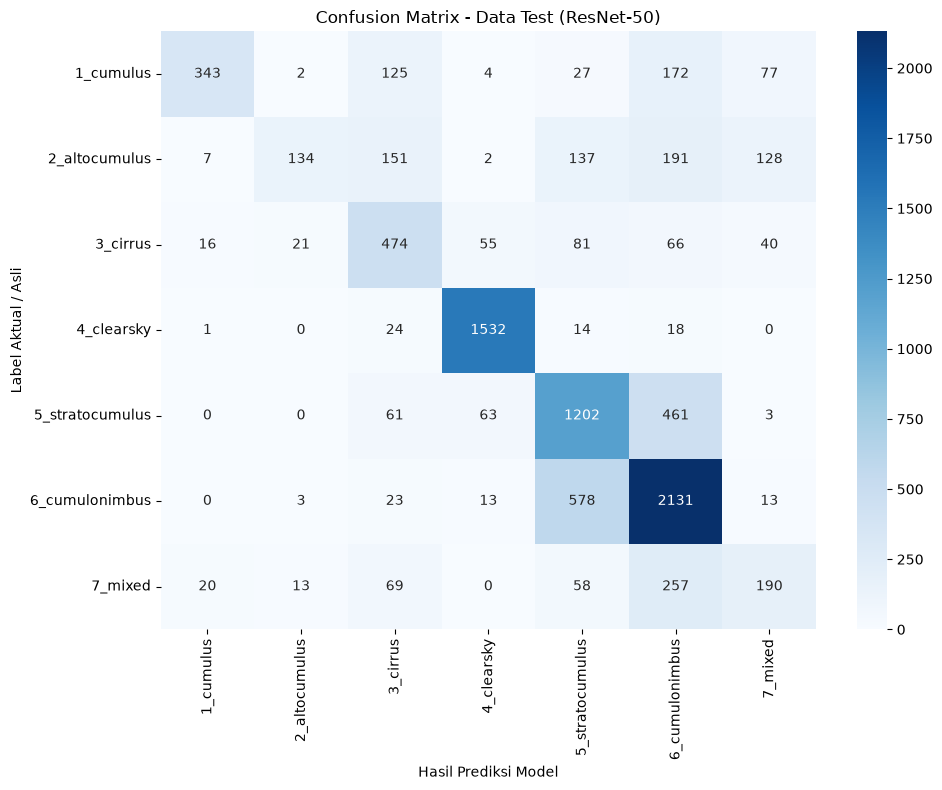

In [27]:
# ==========================================
# 2. MEMUAT ARSITEKTUR & BOBOT MODEL
# ==========================================
model = resnet50()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, NUM_CLASSES)
)

# Muat file .pth hasil training transfer learning kemarin
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval() # Mengaktifkan mode evaluasi (mematikan dropout)

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. TAMPILKAN HASIL AKHIR (CLASSIFICATION REPORT)
# ==========================================
print("\n" + "="*50)
print("         HASIL EVALUASI AKHIR (DATA TEST)        ")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==========================================
# 5. VISUALISASI CONFUSION MATRIX DATA TEST
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Data Test (ResNet-50)')
plt.ylabel('Label Aktual / Asli')
plt.xlabel('Hasil Prediksi Model')
plt.tight_layout()

# Simpan matriks data test secara terpisah
plt.savefig('resnet50_test_confusion_matrix_pipeline.png', dpi=300)
print("\nGrafik Confusion Matrix untuk Data Test telah disimpan dengan nama 'resnet50_test_confusion_matrix_pipeline.png'")
plt.show()

## Define CNN model

In [14]:
# ============================================================================
# 3. KELAS EARLY STOPPING (BARU)
# ============================================================================
class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [15]:
# ============================================================================
# 4. FOCAL LOSS & FUNGSI UNFREEZING
# ============================================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss) 
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

In [16]:
def set_trainable_layers(model, phase):
    """
    Mengatur progressive unfreezing ResNet-50.

    Fase 1 : hanya classifier
    Fase 2 : layer4 dan classifier
    Fase 3 : layer3-layer4 dan classifier
    Fase 4 : layer2-layer4 dan classifier
    Fase 5 : seluruh model
    """
    for param in model.parameters():
        param.requires_grad = False

    trainable_prefixes = {
        1: ("fc",),
        2: ("layer4", "fc"),
        3: ("layer3", "layer4", "fc"),
        4: ("layer2", "layer3", "layer4", "fc"),
    }

    if phase == 5:
        for parameter in model.parameters():
            parameter.requires_grad = True

    elif phase in trainable_prefixes:
        selected_prefixes = trainable_prefixes[phase]

        for name, parameter in model.named_parameters():
            if name.startswith(selected_prefixes):
                parameter.requires_grad = True
    
    else:
        raise ValueError(
            f"Fase {phase} tidak valid. Gunakan fase 1 sampai 5."
        )

    # if phase in [1, 2]:
    #     for param in model.fc.parameters():
    #         param.requires_grad = True
    # elif phase in [3, 4]:
    #     for name, param in model.named_parameters():
    #         if "layer3" in name or "layer4" in name or "fc" in name:
    #             param.requires_grad = True
    # elif phase == 5:
    #     for param in model.parameters():
    #         param.requires_grad = True
    return model

In [ ]:

# ============================================================================
# 5. INISIALISASI MODEL DENGAN DROPOUT (DIPERBARUI)
# ============================================================================
print("Menyiapkan model ResNet-50 dengan Dropout...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Menambahkan lapisan Dropout 50% sebelum lapisan klasifikasi akhir
jumlah_fitur = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(jumlah_fitur, NUM_CLASSES)
)
model = model.to(device)
criterion = FocalLoss(gamma=2)


# ============================================================================
# 6. PIPELINE PELATIHAN UTAMA DENGAN VALIDASI & EARLY STOPPING
# ============================================================================
training_schedule = [
    (1, 10, 0.0001), (2, 10, 0.00001), 
    (3, 20, 0.00005), (4, 20, 0.00001), (5, 20, 0.000001)
]

history = []
best_val_loss = float('inf') 
epoch_keseluruhan = 0

print("\nMemulai Pelatihan...")
for phase, num_epochs, lr in training_schedule:
    print(f"\n{'='*50}")
    print(f"MEMASUKI FASE {phase} | Max Epochs: {num_epochs} | Target LR: {lr}")
    print(f"{'='*50}")
    
    model = set_trainable_layers(model, phase)
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    # optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    optimizer = optim.SGD(
                    model.parameters(), 
                    lr=lr, 
                    momentum=0.9, 
                    weight_decay=1e-4
                )

    early_stopping = EarlyStopping(patience=3) 

    # Menyimpan validation loss dan bobot terbaik pada fase aktif
    best_phase_val_loss = float("inf")
    best_phase_state = None
    
    for epoch in range(num_epochs):
        epoch_keseluruhan += 1
        
        # --- A. FASE TRAINING ---
        model.train()
        train_loss = 0.0
        correct_train_preds = 0
        total_train_preds = 0
        
        for inputs, labels in train_loader: 
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predictions = torch.max(outputs, 1)
            correct_train_preds += (predictions == labels).sum().item()
            total_train_preds += labels.size(0)
            
        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = (correct_train_preds / total_train_preds) * 100
        
        # --- B. FASE VALIDASI ---
        model.eval()
        val_loss = 0.0
        correct_val_preds = 0
        total_val_preds = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predictions = torch.max(outputs, 1)
                correct_val_preds += (predictions == labels).sum().item()
                total_val_preds += labels.size(0)
                
        avg_val_loss = val_loss / len(val_loader)
        val_acc = (correct_val_preds / total_val_preds) * 100
        
        print(f"Phase {phase} - Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        # --- C. CATAT DATA EPOCH KE HISTORY ---
        epoch_metrics = {
            "epoch": epoch_keseluruhan,
            "phase": phase,
            "train_loss": float(avg_train_loss),
            "train_accuracy": float(avg_train_acc),
            "val_loss": float(avg_val_loss),
            "val_accuracy": float(val_acc),
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        history.append(epoch_metrics)

        # --- D. SAVE MODEL CHECKPOINT ---
        # Terbaik dalam fase
        if avg_val_loss < best_phase_val_loss:
            best_phase_val_loss = avg_val_loss
            best_phase_state = {
                name: parameter.detach().clone()
                for name, parameter in model.state_dict().items()
            }

            print(
                f"--> Bobot terbaik Fase {phase} disimpan "
                f"dengan Val Loss: {best_phase_val_loss:.4f}"
            )

        # Terbaik dari seluruh fase
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(
                model.state_dict(),
                MODEL_SAVE_PATH
            )
            
        # --- E. CEK EARLY STOPPING ---
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f">>> Early Stopping terpicu pada Fase {phase}. Lanjut ke fase berikutnya!")
            break

    # Harus berada di luar perulangan epoch
    if best_phase_state is not None:
        model.load_state_dict(best_phase_state)

        print(
            f"Bobot terbaik Fase {phase} dimuat kembali | "
            f"Val Loss: {best_phase_val_loss:.4f}"
        )

# ============================================================================
# 7. PENYIMPANAN LOG KE JSON & CSV
# ============================================================================
print("\nPelatihan selesai seluruhnya!")

# Menyimpan riwayat log sesuai direktori LOG_DIR di notebook Anda
json_path = LOG_DIR / "log_train_baseline_UJI.json"
with open(json_path, "w", encoding="utf-8") as json_file:
    json.dump(history, json_file, indent=4, ensure_ascii=False)
print(f"Berhasil menyimpan log ke '{json_path}'")

csv_path = LOG_DIR / "tabel_log_train_baseline_UJI.csv"
summary_train = pd.DataFrame(history)
summary_train.to_csv(csv_path, index=False)
print(f"Berhasil menyimpan tabel ke '{csv_path}'")

Menyiapkan model ResNet-50 dengan Dropout...

Memulai Pelatihan...

MEMASUKI FASE 1 | Max Epochs: 10 | Target LR: 0.0001
Phase 1 - Epoch [1/10] | Train Loss: 1.0630 | Val Loss: 0.7297 | Val Acc: 74.72%
--> Bobot terbaik Fase 1 disimpan dengan Val Loss: 0.7297
Phase 1 - Epoch [2/10] | Train Loss: 0.7228 | Val Loss: 0.5500 | Val Acc: 76.83%
--> Bobot terbaik Fase 1 disimpan dengan Val Loss: 0.5500
Phase 1 - Epoch [3/10] | Train Loss: 0.5860 | Val Loss: 0.4349 | Val Acc: 77.43%
--> Bobot terbaik Fase 1 disimpan dengan Val Loss: 0.4349
Phase 1 - Epoch [4/10] | Train Loss: 0.5198 | Val Loss: 0.4175 | Val Acc: 78.83%
--> Bobot terbaik Fase 1 disimpan dengan Val Loss: 0.4175
Phase 1 - Epoch [5/10] | Train Loss: 0.4772 | Val Loss: 0.3678 | Val Acc: 78.93%
--> Bobot terbaik Fase 1 disimpan dengan Val Loss: 0.3678
Phase 1 - Epoch [6/10] | Train Loss: 0.4495 | Val Loss: 0.3449 | Val Acc: 79.38%
--> Bobot terbaik Fase 1 disimpan dengan Val Loss: 0.3449
Phase 1 - Epoch [7/10] | Train Loss: 0.4200 |

In [18]:
# ============================================================================
# HEAT MAP — PERSIAPAN MODEL TERBAIK
# ============================================================================

# Memuat checkpoint terbaik dari seluruh fase.
state_dict = torch.load(
    MODEL_SAVE_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

# Memastikan urutan kelas test sama dengan training.
if train_dataset.class_to_idx != test_dataset.class_to_idx:
    raise RuntimeError(
        "Urutan kelas train dan test berbeda.\n"
        f"Train: {train_dataset.class_to_idx}\n"
        f"Test : {test_dataset.class_to_idx}"
    )

print("Model terbaik berhasil dimuat.")
print(f"Target layer Grad-CAM: {model.layer4[-1]}")

Model terbaik berhasil dimuat.
Target layer Grad-CAM: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


In [ ]:
# ============================================================================
# MENGUMPULKAN LABEL DAN PREDIKSI TEST SET
# ============================================================================

all_true_labels = []
all_predictions = []

model.eval()

with torch.inference_mode():

    test_progress = tqdm(
        test_loader,
        desc="Memprediksi test set"
    )

    for inputs, labels in test_progress:

        inputs = inputs.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(inputs)

        predictions = outputs.argmax(dim=1)

        all_true_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_true_labels = np.asarray(all_true_labels)
all_predictions = np.asarray(all_predictions)

test_accuracy = (
    all_predictions == all_true_labels
).mean() * 100

print(f"Jumlah citra test : {len(all_true_labels)}")
print(f"Test accuracy     : {test_accuracy:.2f}%")

Memprediksi test set:   0%|          | 0/282 [00:00<?, ?it/s]

Jumlah citra test : 9000
Test accuracy     : 73.72%


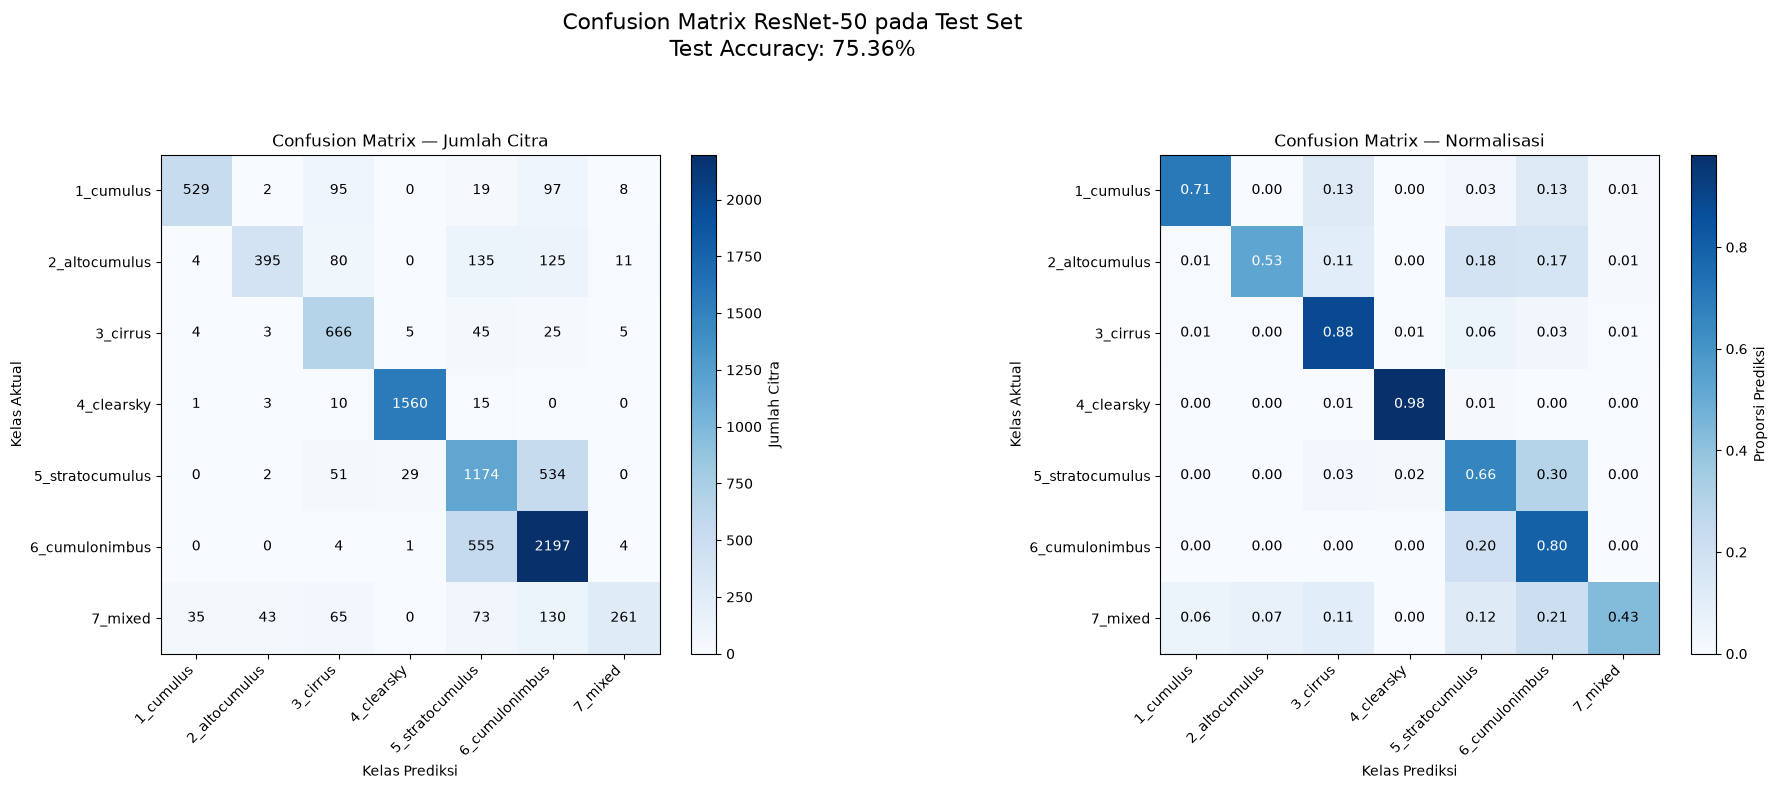

Visualisasi confusion matrix berhasil disimpan:
d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\confusion_matrix_resnet50_all_classes.png


In [35]:
# ============================================================================
# VISUALISASI CONFUSION MATRIX SELURUH KELAS
# ============================================================================

LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(20, 8)
)


# --------------------------------------------------------------------------
# A. CONFUSION MATRIX BERDASARKAN JUMLAH CITRA
# --------------------------------------------------------------------------

raw_image = plot_confusion_heatmap(
    axis=axes[0],
    matrix=confusion_matrix,
    title="Confusion Matrix — Jumlah Citra",
    value_format="d"
)

figure.colorbar(
    raw_image,
    ax=axes[0],
    fraction=0.046,
    pad=0.04,
    label="Jumlah Citra"
)


# --------------------------------------------------------------------------
# B. CONFUSION MATRIX YANG DINORMALISASI
# --------------------------------------------------------------------------

normalized_image = plot_confusion_heatmap(
    axis=axes[1],
    matrix=normalized_confusion_matrix,
    title="Confusion Matrix — Normalisasi",
    value_format=".2f"
)

figure.colorbar(
    normalized_image,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    label="Proporsi Prediksi"
)


# --------------------------------------------------------------------------
# JUDUL UTAMA
# --------------------------------------------------------------------------

figure.suptitle(
    f"Confusion Matrix ResNet-50 pada Test Set\n"
    f"Test Accuracy: {test_accuracy:.2f}%",
    fontsize=16
)

figure.tight_layout(
    rect=[0, 0, 1, 0.93]
)


# --------------------------------------------------------------------------
# MENYIMPAN GAMBAR
# --------------------------------------------------------------------------

confusion_figure_path = (
    LOG_DIR /
    "confusion_matrix_resnet50_all_classes.png"
)

figure.savefig(
    confusion_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Visualisasi confusion matrix berhasil disimpan:\n"
    f"{confusion_figure_path}"
)

In [37]:
def plot_normalized_confusion_matrix(
    axis,
    matrix,
    class_names
):
    """
    Menampilkan normalized confusion matrix dalam persentase.
    """

    image = axis.imshow(
        matrix,
        cmap="Blues",
        interpolation="nearest",
        vmin=0,
        vmax=1
    )

    axis.set_title(
        "Normalized Confusion Matrix"
    )

    axis.set_xlabel(
        "Kelas Prediksi"
    )

    axis.set_ylabel(
        "Kelas Aktual"
    )

    axis.set_xticks(
        np.arange(len(class_names))
    )

    axis.set_yticks(
        np.arange(len(class_names))
    )

    axis.set_xticklabels(
        class_names,
        rotation=45,
        ha="right"
    )

    axis.set_yticklabels(
        class_names
    )

    for actual_class in range(len(class_names)):
        for predicted_class in range(len(class_names)):

            value = matrix[
                actual_class,
                predicted_class
            ]

            axis.text(
                predicted_class,
                actual_class,
                f"{value * 100:.1f}%",
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > 0.5
                    else "black"
                )
            )

    return image

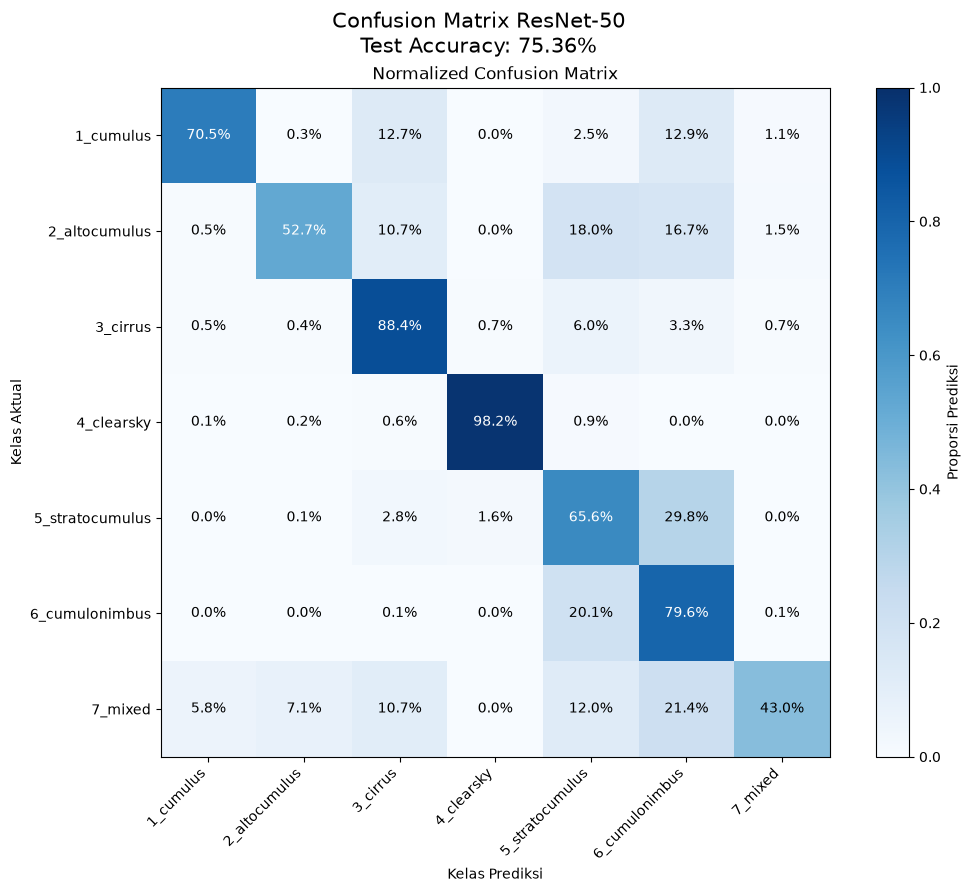

Gambar disimpan di: d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\normalized_confusion_matrix_resnet50.png


In [38]:
figure, axis = plt.subplots(
    figsize=(11, 9)
)

image = plot_normalized_confusion_matrix(
    axis=axis,
    matrix=normalized_confusion_matrix,
    class_names=class_names
)

figure.colorbar(
    image,
    ax=axis,
    label="Proporsi Prediksi"
)

figure.suptitle(
    f"Confusion Matrix ResNet-50\n"
    f"Test Accuracy: {test_accuracy:.2f}%",
    fontsize=15
)

figure.tight_layout()

normalized_path = (
    LOG_DIR /
    "normalized_confusion_matrix_resnet50.png"
)

figure.savefig(
    normalized_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gambar disimpan di: {normalized_path}")

In [30]:
# ============================================================================
# PRECISION, RECALL, DAN F1-SCORE SETIAP KELAS
# ============================================================================

# True Positive setiap kelas berada pada diagonal confusion matrix.
true_positive = np.diag(
    confusion_matrix
).astype(float)

# False Positive:
# jumlah prediksi pada suatu kelas dikurangi True Positive.
false_positive = (
    confusion_matrix.sum(axis=0)
    - true_positive
)

# False Negative:
# jumlah data aktual pada suatu kelas dikurangi True Positive.
false_negative = (
    confusion_matrix.sum(axis=1)
    - true_positive
)

# Jumlah data aktual setiap kelas.
support = confusion_matrix.sum(
    axis=1
).astype(int)


# --------------------------------------------------------------------------
# PRECISION
# --------------------------------------------------------------------------

precision = np.divide(
    true_positive,
    true_positive + false_positive,
    out=np.zeros_like(
        true_positive,
        dtype=float
    ),
    where=(
        true_positive + false_positive
    ) != 0
)


# --------------------------------------------------------------------------
# RECALL
# --------------------------------------------------------------------------

recall = np.divide(
    true_positive,
    true_positive + false_negative,
    out=np.zeros_like(
        true_positive,
        dtype=float
    ),
    where=(
        true_positive + false_negative
    ) != 0
)


# --------------------------------------------------------------------------
# F1-SCORE
# --------------------------------------------------------------------------

f1_score = np.divide(
    2 * precision * recall,
    precision + recall,
    out=np.zeros_like(
        precision,
        dtype=float
    ),
    where=(
        precision + recall
    ) != 0
)

In [31]:
# ============================================================================
# TABEL METRIK SETIAP KELAS
# ============================================================================

class_metrics = pd.DataFrame({
    "class_index": np.arange(NUM_CLASSES),
    "class_name": class_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1_score,
    "support": support
})

print("=" * 85)
print("PRECISION, RECALL, DAN F1-SCORE SETIAP KELAS")
print("=" * 85)

display(
    class_metrics.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1_score": "{:.4f}",
        "support": "{:,}"
    })
)

PRECISION, RECALL, DAN F1-SCORE SETIAP KELAS


,class_index,class_name,precision,recall,f1_score,support
0,0,1_cumulus,0.9232,0.7053,0.7997,750
1,1,2_altocumulus,0.8817,0.5267,0.6594,750
2,2,3_cirrus,0.6859,0.8845,0.7726,753
3,3,4_clearsky,0.9781,0.9817,0.9799,"1,589"
4,4,5_stratocumulus,0.5823,0.6559,0.6169,"1,790"
5,5,6_cumulonimbus,0.7069,0.7957,0.7487,"2,761"
6,6,7_mixed,0.9031,0.4300,0.5826,607


In [32]:
# ============================================================================
# MACRO AVERAGE, WEIGHTED AVERAGE, DAN ACCURACY
# ============================================================================

total_samples = support.sum()

accuracy = (
    true_positive.sum()
    / total_samples
)

macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1_score.mean()

weighted_precision = np.average(
    precision,
    weights=support
)

weighted_recall = np.average(
    recall,
    weights=support
)

weighted_f1 = np.average(
    f1_score,
    weights=support
)


overall_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score"
    ],
    "value": [
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

print("\n" + "=" * 55)
print("RINGKASAN METRIK MODEL")
print("=" * 55)

display(
    overall_metrics.style.format({
        "value": "{:.4f}"
    })
)


RINGKASAN METRIK MODEL


,metric,value
0,Accuracy,0.7536
1,Macro Precision,0.8087
2,Macro Recall,0.7114
3,Macro F1-score,0.7371
4,Weighted Precision,0.7741
5,Weighted Recall,0.7536
6,Weighted F1-score,0.7509


In [33]:
# ============================================================================
# MENYIMPAN HASIL EVALUASI
# ============================================================================

LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

per_class_csv_path = (
    LOG_DIR /
    "precision_recall_f1_per_class.csv"
)

overall_csv_path = (
    LOG_DIR /
    "overall_classification_metrics.csv"
)

metrics_json_path = (
    LOG_DIR /
    "classification_metrics.json"
)


# Menyimpan tabel per kelas.
class_metrics.to_csv(
    per_class_csv_path,
    index=False
)

# Menyimpan metrik keseluruhan.
overall_metrics.to_csv(
    overall_csv_path,
    index=False
)


# Membuat struktur JSON.
metrics_data = {
    "model": MODEL_NAME,
    "checkpoint": str(MODEL_SAVE_PATH),
    "total_test_samples": int(total_samples),
    "accuracy": float(accuracy),
    "macro_average": {
        "precision": float(macro_precision),
        "recall": float(macro_recall),
        "f1_score": float(macro_f1)
    },
    "weighted_average": {
        "precision": float(weighted_precision),
        "recall": float(weighted_recall),
        "f1_score": float(weighted_f1)
    },
    "per_class": class_metrics.to_dict(
        orient="records"
    )
}

with open(
    metrics_json_path,
    mode="w",
    encoding="utf-8"
) as json_file:

    json.dump(
        metrics_data,
        json_file,
        indent=4,
        ensure_ascii=False
    )


print("Hasil evaluasi berhasil disimpan:")
print(f"1. Per kelas : {per_class_csv_path}")
print(f"2. Ringkasan : {overall_csv_path}")
print(f"3. JSON      : {metrics_json_path}")

Hasil evaluasi berhasil disimpan:
1. Per kelas : d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\precision_recall_f1_per_class.csv
2. Ringkasan : d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\overall_classification_metrics.csv
3. JSON      : d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\classification_metrics.json


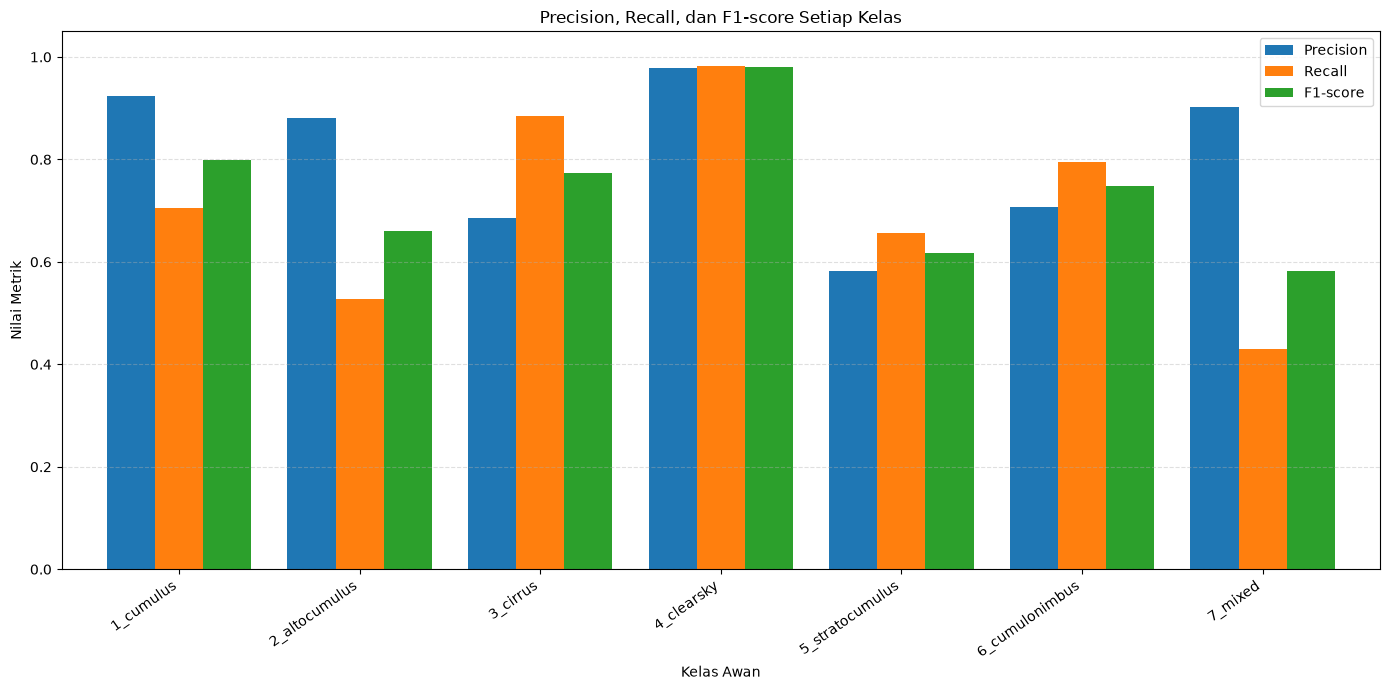

Grafik metrik disimpan di:
d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\precision_recall_f1_per_class.png


In [34]:
# ============================================================================
# VISUALISASI PRECISION, RECALL, DAN F1-SCORE
# ============================================================================

metric_columns = [
    "precision",
    "recall",
    "f1_score"
]

axis = (
    class_metrics
    .set_index("class_name")[metric_columns]
    .plot(
        kind="bar",
        figsize=(14, 7),
        width=0.8
    )
)

axis.set_title(
    "Precision, Recall, dan F1-score Setiap Kelas"
)

axis.set_xlabel("Kelas Awan")
axis.set_ylabel("Nilai Metrik")
axis.set_ylim(0, 1.05)

axis.set_xticklabels(
    class_names,
    rotation=35,
    ha="right"
)

axis.legend([
    "Precision",
    "Recall",
    "F1-score"
])

axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

figure = axis.get_figure()
figure.tight_layout()

metric_figure_path = (
    LOG_DIR /
    "precision_recall_f1_per_class.png"
)

figure.savefig(
    metric_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Grafik metrik disimpan di:\n"
    f"{metric_figure_path}"
)

In [18]:
def plot_confusion_heatmap(
    axis,
    matrix,
    title,
    value_format
):
    """
    Menampilkan confusion matrix sebagai heat map.
    """

    image = axis.imshow(
        matrix,
        interpolation="nearest",
        cmap="Blues",
        vmin=0
    )

    axis.set_title(title)
    axis.set_xlabel("Kelas Prediksi")
    axis.set_ylabel("Kelas Aktual")

    axis.set_xticks(
        np.arange(NUM_CLASSES)
    )

    axis.set_yticks(
        np.arange(NUM_CLASSES)
    )

    axis.set_xticklabels(
        class_names,
        rotation=45,
        ha="right"
    )

    axis.set_yticklabels(
        class_names
    )

    threshold = (
        matrix.max() / 2
        if matrix.max() > 0
        else 0
    )

    for row in range(NUM_CLASSES):
        for column in range(NUM_CLASSES):

            value = matrix[row, column]

            axis.text(
                column,
                row,
                format(value, value_format),
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                )
            )

    return image

In [19]:
def plot_confusion_heatmap(
    axis,
    matrix,
    title,
    value_format
):
    """
    Menampilkan confusion matrix sebagai heat map.
    """

    image = axis.imshow(
        matrix,
        interpolation="nearest",
        cmap="Blues",
        vmin=0
    )

    axis.set_title(title)
    axis.set_xlabel("Kelas Prediksi")
    axis.set_ylabel("Kelas Aktual")

    axis.set_xticks(
        np.arange(NUM_CLASSES)
    )

    axis.set_yticks(
        np.arange(NUM_CLASSES)
    )

    axis.set_xticklabels(
        class_names,
        rotation=45,
        ha="right"
    )

    axis.set_yticklabels(
        class_names
    )

    threshold = (
        matrix.max() / 2
        if matrix.max() > 0
        else 0
    )

    for row in range(NUM_CLASSES):
        for column in range(NUM_CLASSES):

            value = matrix[row, column]

            axis.text(
                column,
                row,
                format(value, value_format),
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                )
            )

    return image

In [20]:
# ============================================================================
# KELAS GRAD-CAM UNTUK RESNET-50
# ============================================================================

class GradCAM:
    def __init__(
        self,
        model,
        target_layer
    ):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

    def _save_gradient(self, gradient):
        self.gradients = gradient.detach()

    def _forward_hook(
        self,
        module,
        module_input,
        module_output
    ):
        self.activations = module_output.detach()

        # Menangkap gradient dari output target layer.
        module_output.register_hook(
            self._save_gradient
        )

    def generate(
        self,
        image,
        target_class
    ):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        input_tensor = (
            image
            .unsqueeze(0)
            .to(DEVICE)
            .requires_grad_(True)
        )

        outputs = self.model(input_tensor)

        target_score = outputs[
            0,
            target_class
        ]

        target_score.backward()

        if (
            self.activations is None
            or self.gradients is None
        ):
            raise RuntimeError(
                "Aktivasi atau gradient tidak berhasil direkam."
            )

        # Global average pooling terhadap gradient.
        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Menggabungkan activation map berdasarkan bobot gradient.
        cam = (
            weights * self.activations
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = torch.relu(cam)

        # Mengubah ukuran heat map sesuai ukuran citra.
        cam = torch.nn.functional.interpolate(
            cam,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        # Normalisasi menjadi 0–1.
        cam_min = cam.min()
        cam_max = cam.max()

        cam = (
            cam - cam_min
        ) / (
            cam_max - cam_min + 1e-8
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_class = int(
            outputs.argmax(dim=1).item()
        )

        confidence = float(
            probabilities[
                0,
                predicted_class
            ].item()
        )

        return (
            cam.squeeze().cpu().numpy(),
            predicted_class,
            confidence
        )

    def close(self):
        self.forward_handle.remove()

In [21]:
# ============================================================================
# MEMILIH SATU CITRA REPRESENTATIF PER KELAS
# ============================================================================

correct_samples = {}
fallback_samples = {}

model.eval()

with torch.inference_mode():

    for images, labels in tqdm(
        test_loader,
        desc="Memilih citra setiap kelas"
    ):

        outputs = model(
            images.to(DEVICE)
        )

        predictions = outputs.argmax(dim=1).cpu()

        for index in range(labels.size(0)):

            true_class = int(
                labels[index].item()
            )

            predicted_class = int(
                predictions[index].item()
            )

            # Menyimpan citra pertama sebagai cadangan.
            if true_class not in fallback_samples:
                fallback_samples[true_class] = (
                    images[index].cpu(),
                    predicted_class
                )

            # Memprioritaskan citra yang diprediksi benar.
            if (
                true_class == predicted_class
                and true_class not in correct_samples
            ):
                correct_samples[true_class] = (
                    images[index].cpu(),
                    predicted_class
                )

        if len(correct_samples) == NUM_CLASSES:
            break


selected_samples = {}

for class_index in range(NUM_CLASSES):

    if class_index in correct_samples:
        selected_samples[class_index] = (
            correct_samples[class_index]
        )

    elif class_index in fallback_samples:
        selected_samples[class_index] = (
            fallback_samples[class_index]
        )

    else:
        raise RuntimeError(
            f"Tidak ada citra untuk kelas "
            f"{class_names[class_index]}."
        )

print(
    f"Berhasil memilih citra dari "
    f"{len(selected_samples)} kelas."
)

Memilih citra setiap kelas:   0%|          | 0/282 [00:00<?, ?it/s]

Berhasil memilih citra dari 7 kelas.


In [22]:
# ============================================================================
# DENORMALISASI CITRA
# ============================================================================

imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize_image(image):
    """
    Mengembalikan citra dari normalisasi ImageNet ke RGB 0–1.
    """

    restored_image = (
        image.cpu() * imagenet_std
        + imagenet_mean
    )

    restored_image = restored_image.clamp(
        0,
        1
    )

    return restored_image.permute(
        1,
        2,
        0
    ).numpy()

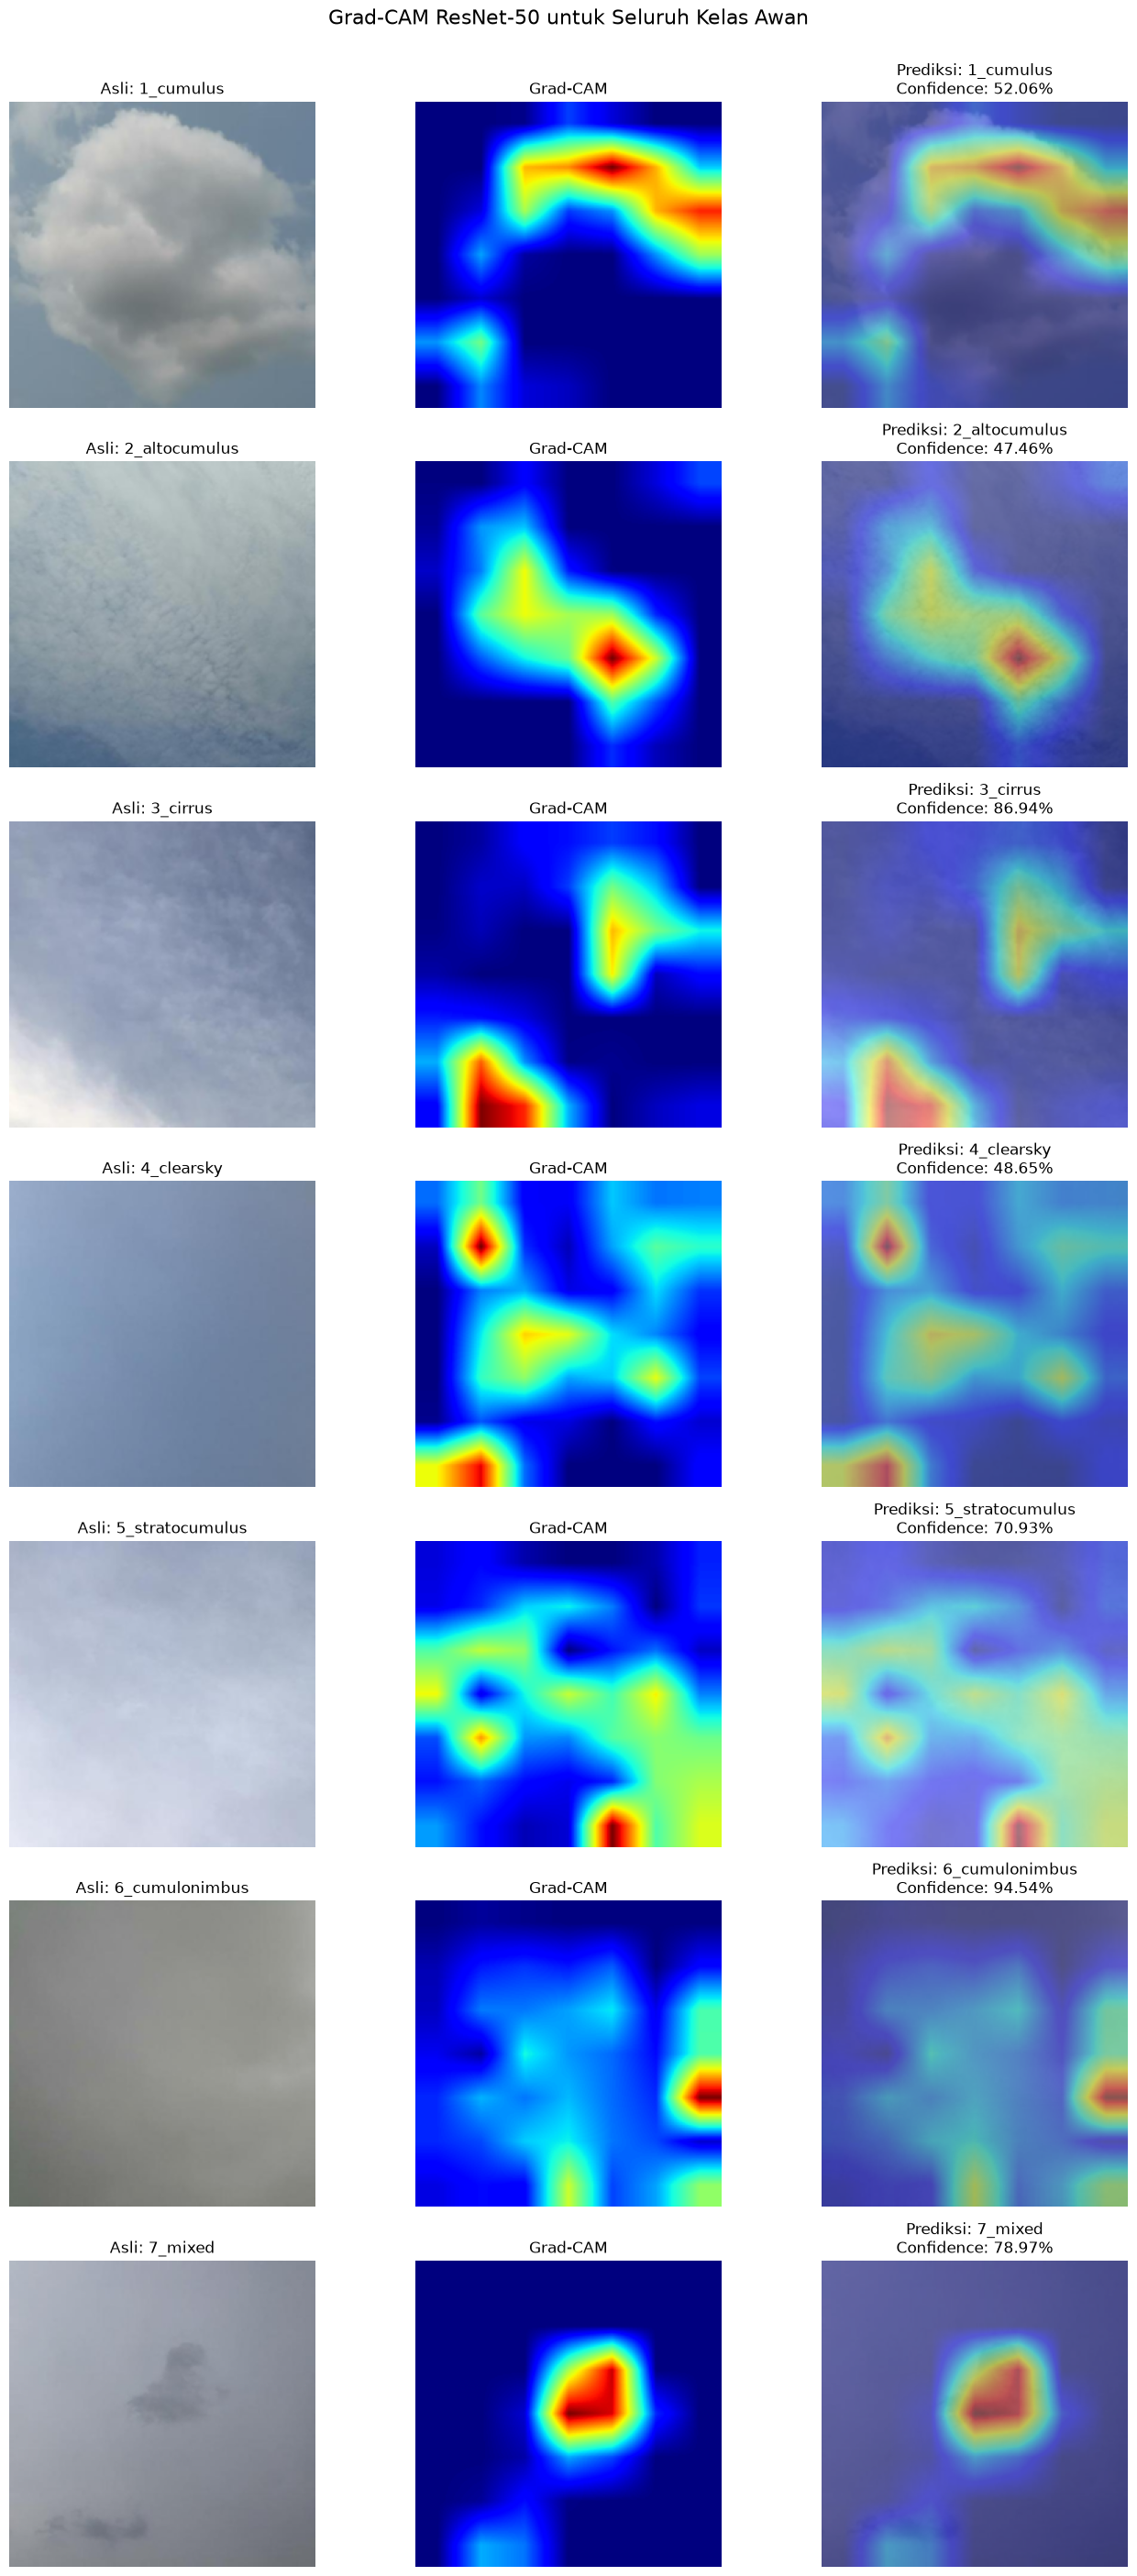

Grad-CAM disimpan: d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\gradcam_all_classes_resnet50.png


In [23]:
# ============================================================================
# GRAD-CAM SATU CITRA UNTUK SETIAP KELAS
# ============================================================================

target_layer = model.layer4[-1]

gradcam = GradCAM(
    model=model,
    target_layer=target_layer
)

figure, axes = plt.subplots(
    nrows=NUM_CLASSES,
    ncols=3,
    figsize=(14, 4 * NUM_CLASSES)
)

for class_index in range(NUM_CLASSES):

    image_tensor, _ = selected_samples[
        class_index
    ]

    heatmap, predicted_class, confidence = (
        gradcam.generate(
            image=image_tensor,
            target_class=class_index
        )
    )

    original_image = denormalize_image(
        image_tensor
    )

    # Kolom 1: citra asli.
    axes[class_index, 0].imshow(
        original_image
    )

    axes[class_index, 0].set_title(
        f"Asli: {class_names[class_index]}"
    )

    # Kolom 2: heat map.
    axes[class_index, 1].imshow(
        heatmap,
        cmap="jet",
        vmin=0,
        vmax=1
    )

    axes[class_index, 1].set_title(
        "Grad-CAM"
    )

    # Kolom 3: overlay citra dan heat map.
    axes[class_index, 2].imshow(
        original_image
    )

    axes[class_index, 2].imshow(
        heatmap,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )

    axes[class_index, 2].set_title(
        f"Prediksi: {class_names[predicted_class]}\n"
        f"Confidence: {confidence:.2%}"
    )

    for column in range(3):
        axes[class_index, column].axis("off")

figure.suptitle(
    "Grad-CAM ResNet-50 untuk Seluruh Kelas Awan",
    fontsize=16,
    y=1.002
)

figure.tight_layout()

gradcam_path = (
    LOG_DIR /
    "gradcam_all_classes_resnet50.png"
)

figure.savefig(
    gradcam_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

gradcam.close()

print(f"Grad-CAM disimpan: {gradcam_path}")

In [24]:
# ============================================================================
# MEMILIH SATU CITRA DARI SETIAP KELAS
# ============================================================================

model.eval()

MODEL_DEVICE = next(
    model.parameters()
).device

correct_samples = {}
fallback_samples = {}

with torch.inference_mode():

    for images, labels in tqdm(
        test_loader,
        desc="Memilih citra setiap kelas"
    ):

        outputs = model(
            images.to(MODEL_DEVICE)
        )

        predictions = outputs.argmax(
            dim=1
        ).cpu()

        for index in range(labels.size(0)):

            actual_class = int(
                labels[index].item()
            )

            predicted_class = int(
                predictions[index].item()
            )

            # Citra cadangan apabila tidak ditemukan prediksi benar.
            if actual_class not in fallback_samples:
                fallback_samples[actual_class] = (
                    images[index].cpu(),
                    predicted_class
                )

            # Memilih citra yang diprediksi dengan benar.
            if (
                actual_class == predicted_class
                and actual_class not in correct_samples
            ):
                correct_samples[actual_class] = (
                    images[index].cpu(),
                    predicted_class
                )

        if len(correct_samples) == NUM_CLASSES:
            break


selected_samples = {}

for class_index in range(NUM_CLASSES):

    if class_index in correct_samples:
        selected_samples[class_index] = (
            correct_samples[class_index]
        )

    elif class_index in fallback_samples:
        selected_samples[class_index] = (
            fallback_samples[class_index]
        )

    else:
        raise RuntimeError(
            f"Citra kelas {class_names[class_index]} "
            "tidak ditemukan."
        )

print(
    f"Berhasil memilih citra dari "
    f"{len(selected_samples)} kelas."
)

Memilih citra setiap kelas:   0%|          | 0/282 [00:00<?, ?it/s]

Berhasil memilih citra dari 7 kelas.


In [25]:
# ============================================================================
# FEATURE MAP EXTRACTOR RESNET-50
# ============================================================================

class FeatureMapExtractor:
    def __init__(
        self,
        model,
        target_layers
    ):
        self.model = model
        self.target_layers = target_layers
        self.feature_maps = {}
        self.handles = []

        for layer_name, layer_module in target_layers.items():

            handle = layer_module.register_forward_hook(
                self._create_hook(layer_name)
            )

            self.handles.append(handle)

    def _create_hook(self, layer_name):

        def hook(
            module,
            module_input,
            module_output
        ):
            self.feature_maps[layer_name] = (
                module_output.detach().cpu()
            )

        return hook

    def clear(self):
        self.feature_maps.clear()

    def close(self):

        for handle in self.handles:
            handle.remove()

        self.handles.clear()

In [26]:
# ============================================================================
# LAPISAN YANG AKAN DIVISUALISASIKAN
# ============================================================================

target_layers = {
    "conv1": model.relu,
    "layer1": model.layer1[-1],
    "layer2": model.layer2[-1],
    "layer3": model.layer3[-1],
    "layer4": model.layer4[-1]
}

feature_extractor = FeatureMapExtractor(
    model=model,
    target_layers=target_layers
)

In [27]:
# ============================================================================
# MENGEMBALIKAN CITRA KE WARNA RGB
# ============================================================================

imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize_image(image):

    image = (
        image.cpu() * imagenet_std
        + imagenet_mean
    )

    image = image.clamp(
        min=0,
        max=1
    )

    return image.permute(
        1,
        2,
        0
    ).numpy()

In [28]:
def create_activation_heatmap(feature_map):
    """
    Menggabungkan seluruh kanal feature map menjadi satu heat map.
    """

    # Menghapus dimensi batch.
    feature_map = feature_map.squeeze(0)

    # Menggabungkan aktivasi seluruh kanal.
    heatmap = feature_map.mean(
        dim=0
    )

    # Normalisasi ke rentang 0–1.
    heatmap_min = heatmap.min()
    heatmap_max = heatmap.max()

    heatmap = (
        heatmap - heatmap_min
    ) / (
        heatmap_max - heatmap_min + 1e-8
    )

    return heatmap.numpy()

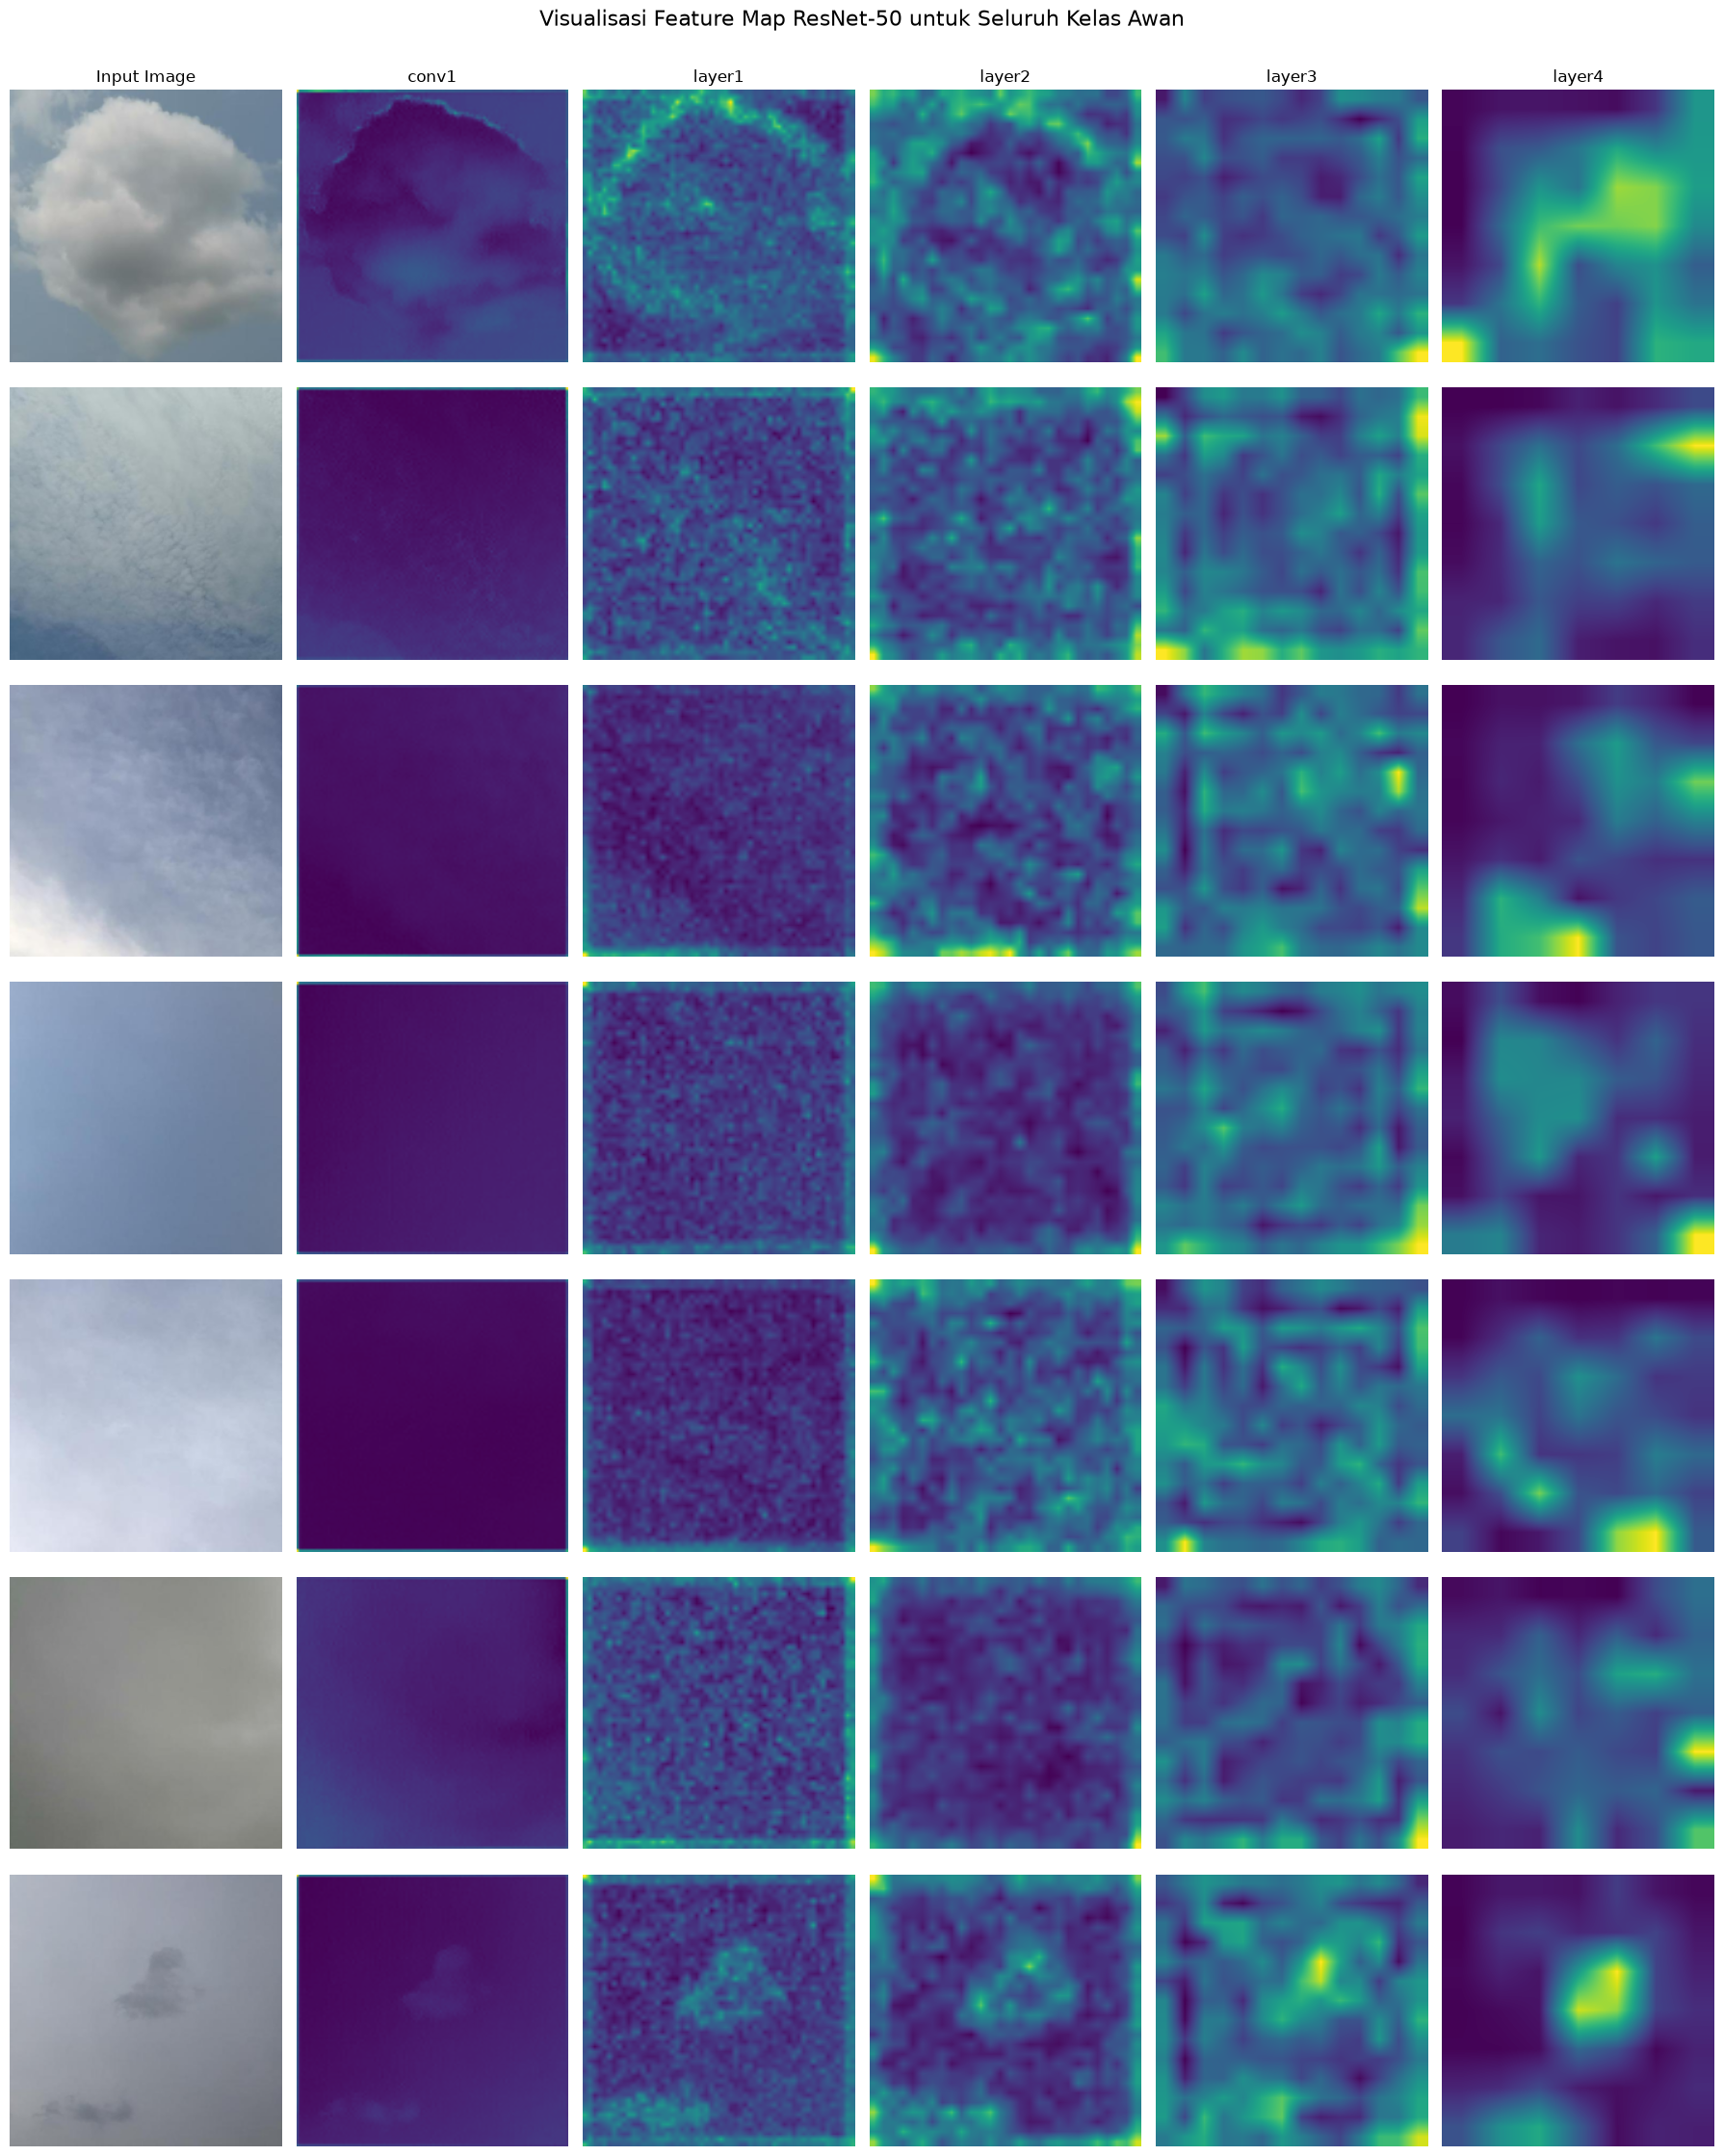

Visualisasi feature map disimpan di:
d:\n8n-logsiswaparalayang\cloud-classification\logs\traning\feature_map_semua_kelas_resnet50.png


In [29]:
# ============================================================================
# VISUALISASI FEATURE MAP SELURUH KELAS
# ============================================================================

layer_names = list(
    target_layers.keys()
)

number_of_columns = (
    len(layer_names) + 1
)

figure, axes = plt.subplots(
    nrows=NUM_CLASSES,
    ncols=number_of_columns,
    figsize=(18, 3.2 * NUM_CLASSES)
)

model.eval()

for class_index in range(NUM_CLASSES):

    image_tensor, saved_prediction = (
        selected_samples[class_index]
    )

    input_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(MODEL_DEVICE)
    )

    feature_extractor.clear()

    with torch.inference_mode():

        outputs = model(input_tensor)

        predicted_class = int(
            outputs.argmax(dim=1).item()
        )

        confidence = float(
            torch.softmax(
                outputs,
                dim=1
            )[0, predicted_class].item()
        )

    original_image = denormalize_image(
        image_tensor
    )

    # ---------------------------------------------------------------
    # KOLOM PERTAMA: CITRA INPUT
    # ---------------------------------------------------------------

    axes[class_index, 0].imshow(
        original_image
    )

    axes[class_index, 0].set_ylabel(
        f"Aktual:\n{class_names[class_index]}\n\n"
        f"Prediksi:\n{class_names[predicted_class]}\n"
        f"{confidence:.1%}",
        rotation=0,
        labelpad=65,
        va="center"
    )

    if class_index == 0:
        axes[class_index, 0].set_title(
            "Input Image"
        )

    axes[class_index, 0].axis("off")

    # ---------------------------------------------------------------
    # FEATURE MAP SETIAP LAPISAN
    # ---------------------------------------------------------------

    for column_index, layer_name in enumerate(
        layer_names,
        start=1
    ):

        feature_map = (
            feature_extractor
            .feature_maps[layer_name]
        )

        heatmap = create_activation_heatmap(
            feature_map
        )

        axes[
            class_index,
            column_index
        ].imshow(
            heatmap,
            cmap="viridis",
            interpolation="bilinear"
        )

        if class_index == 0:
            axes[
                class_index,
                column_index
            ].set_title(
                layer_name
            )

        axes[
            class_index,
            column_index
        ].axis("off")


figure.suptitle(
    "Visualisasi Feature Map ResNet-50 "
    "untuk Seluruh Kelas Awan",
    fontsize=16,
    y=1.002
)

figure.tight_layout()

feature_map_path = (
    LOG_DIR /
    "feature_map_semua_kelas_resnet50.png"
)

figure.savefig(
    feature_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature_extractor.close()

print(
    f"Visualisasi feature map disimpan di:\n"
    f"{feature_map_path}"
)